# Mini RAG Learning Lab — from PDF to vector search to answer

A single Colab notebook that walks through every step of a RAG pipeline without
LangChain or any other high-level wrapper. Every intermediate value is printed:
tokens, token IDs, embedding vectors, similarity scores, re-ranking scores, the
exact prompt, and the final grounded answer.

Expected runtime on a free Colab CPU instance: about 5–10 minutes, most of it
model downloads.

The chain the notebook follows:

```
PDF → text → chunks → tokens → token IDs → embedding lookup → vectors
→ Transformer/embedding model → final chunk embedding → vector database
→ query embedding → similarity search → retrieval → re-ranking → context → LLM answer
```

## README — what this notebook teaches and how to use it

I built this to understand RAG properly before ML interviews, so the notebook is
organised as a sequence of small lessons rather than as a black-box pipeline.
Each stage prints its actual input and output, so nothing happens off-screen.

**What it teaches**

Every stage of a RAG pipeline from the inside: what a token ID actually is, where
embedding numbers come from (learned parameters + gradient descent), how
self-attention computes contextual vectors, what cosine similarity measures, what
a vector database does and does not do, and how retrieval, re-ranking, prompting
and generation fit together.

**Architecture**

- *Ingestion (offline):* PDF → text extraction → chunking → embedding model → vector DB.
- *Query (online):* question → query embedding → vector search → top-K →
  cross-encoder re-ranking → prompt → LLM → grounded answer with citation.

**Setup**

Upload this notebook to Google Colab and run the cells top to bottom. The first
code cell installs PyMuPDF, sentence-transformers, chromadb, scikit-learn,
matplotlib, ipywidgets and pandas. Section 18 (the final LLM cell) optionally
takes an API key from any OpenAI-compatible provider (OpenCode Go, OpenAI,
Gemini, Groq or a custom base URL); without a key it finishes in a clearly
labelled demo mode, so the pipeline always completes.

**Section map**

| # | Section | # | Section |
|---|---------|---|---------|
| 1 | RAG overview | 14 | Vector database (ChromaDB) |
| 2 | PDF text extraction (PyMuPDF) | 15 | Top-K retrieval |
| 3 | Chunking + overlap | 16 | Cross-encoder re-ranking |
| 4–13 | Embedding journey (10 lessons) | 17 | Building the RAG prompt |
| | — tokens, token IDs, embedding matrix, | 18 | Final LLM answer (or demo mode) |
| | learned values, attention, pooling, | 19 | Visual pipeline dashboard |
| | real MiniLM, cosine similarity | 20 | Interactive widgets |
| | | 21 | Six failure experiments |
| | | 22 | RAG vs fine-tuning |
| | | 23 | Architecture + end-to-end run_rag() |
| | | 24 | Code quality + LangChain mapping |
| | | 25 | Interview notes + cheat sheet + glossary |

**Toy math vs real model behaviour**

Cells that use small hand-made numbers are always labelled "toy example — not
real model output". Cells that print values produced by the real model are
labelled "actual output". The two are never mixed.

**How I explain this project in an interview**

"Documents are chunked and embedded once at ingestion time into a vector
database. At query time the question is embedded with the same model, the
database returns the top-K chunks by cosine similarity, a cross-encoder re-ranks
those candidates for precise relevance, and the best chunks go into a prompt so
the LLM answers from grounded context instead of memory."

In [ ]:

# SETUP — run this cell once (fresh Colab runtime: takes ~1-2 min, mostly downloads)
#   PyMuPDF (fitz)        -> create + read PDFs
#   sentence-transformers -> real embedding model + real cross-encoder re-ranker
#   chromadb              -> local vector database
#   scikit-learn          -> PCA + cosine similarity helpers
#   matplotlib / pandas / ipywidgets -> visuals and interactivity

!pip install -q --upgrade pymupdf sentence-transformers chromadb scikit-learn matplotlib ipywidgets pandas

import getpass
import json
import os
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import fitz  # PyMuPDF

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_colwidth", 60)

print("Environment ready")
print("   numpy", np.__version__, "| PyMuPDF", getattr(fitz, "VersionBind", "loaded"))

Environment ready
   numpy 2.5.1 | PyMuPDF 1.28.2


---

# Section 1 — RAG overview

**Simple definition.** RAG = Retrieval + Augmented + Generation. Instead of
asking an LLM to answer from its (possibly stale or wrong) memory, we first
retrieve relevant documents, augment the prompt with that retrieved context, and
let the LLM generate an answer grounded in the context.

**Intuition.** An LLM alone is like an expert taking a closed-book exam. RAG
hands the expert an open book, opened to the exact pages they need.

**The high-level flow**

```
USER QUESTION
      ↓
RETRIEVAL          (find the most relevant chunks of our documents)
      ↓
RELEVANT CONTEXT   (the retrieved chunks, pasted into the prompt)
      ↓
LLM                (reads question + context, writes an answer)
      ↓
ANSWER             (grounded in the supplied context, not in fuzzy memory)
```

**Key points**

- RAG has two phases. *Ingestion* (offline): documents → chunks → embeddings →
  vector DB. *Query* (online): question → embedding → search → retrieve →
  re-rank → prompt → LLM.
- Keep that separation in mind — the notebook builds ingestion first, then
  query time.

**Interview question: What is RAG and why do we need it?**
RAG retrieves relevant external context and injects it into the LLM prompt, so
the answer is grounded in up-to-date, domain-specific information. It reduces
hallucination and avoids expensive fine-tuning when knowledge changes often.

---

# Section 2 — PDF text extraction

**Simple definition.** Before a machine can do anything with a document, the
text has to be pulled out of the binary PDF format and turned into a plain
Python string.

**The transformation**

```
PDF (binary file)
      ↓  PDF parser (PyMuPDF = fitz)
pages   → list of Page objects (layout, coordinates, fonts...)
      ↓  page.get_text()
text    → plain string per page
```

**Step 1 — create the tiny document: `leave_policy.pdf`.** The notebook
generates the PDF programmatically so the project is fully self-contained.

In [ ]:

# The whole "document corpus" of this project: ONE small leave-policy PDF.
POLICY_TEXT = """COMPANY LEAVE POLICY

Annual Leave:
Employees receive 18 days of annual leave per year.

Sick Leave:
Employees receive 10 days of paid sick leave per year.

Maternity Leave:
Female employees receive 26 weeks of paid maternity leave.

Paternity Leave:
Employees receive 7 days of paid paternity leave.

Work From Home:
Employees may work remotely up to 2 days per week with manager approval.
"""

def create_leave_policy_pdf(path="leave_policy.pdf", text=POLICY_TEXT):
    """Create a real PDF file with PyMuPDF."""
    doc = fitz.open()
    page = doc.new_page()                                    # one A4 page
    rect = fitz.Rect(72, 72, page.rect.width - 72, page.rect.height - 72)
    page.insert_textbox(rect, text, fontsize=13, fontname="helv")
    doc.save(path)
    doc.close()
    return path

pdf_path = create_leave_policy_pdf()
print(f"Created {pdf_path!r} ({os.path.getsize(pdf_path):,} bytes, real PDF on disk)")

Created 'leave_policy.pdf' (1,163 bytes, real PDF on disk)



## Step 2 — Extract text + metadata

**Metadata matters for citations.** At the end of the pipeline we want to say
*"Answer based on `leave_policy.pdf`, page 1"* — so every piece of text must carry its source
with it through the entire journey.

In [ ]:

def extract_pdf(path):
    """PDF -> list of document objects: {'text': str, 'metadata': dict}."""
    doc = fitz.open(path)
    pages = []
    for page_no, page in enumerate(doc, start=1):
        pages.append({
            "text": page.get_text().strip(),
            "metadata": {
                "source": os.path.basename(path),
                "page": page_no,
            },
        })
    doc.close()
    return pages

pages = extract_pdf(pdf_path)
print(f"ACTUAL OUTPUT — extracted {len(pages)} page(s)\n")
for p in pages:
    print(json.dumps(p, indent=2))

ACTUAL OUTPUT — extracted 1 page(s)

{
  "text": "COMPANY LEAVE POLICY\nAnnual Leave:\nEmployees receive 18 days of annual leave per year.\nSick Leave:\nEmployees receive 10 days of paid sick leave per year.\nMaternity Leave:\nFemale employees receive 26 weeks of paid maternity leave.\nPaternity Leave:\nEmployees receive 7 days of paid paternity leave.\nWork From Home:\nEmployees may work remotely up to 2 days per week with manager approval.",
  "metadata": {
    "source": "leave_policy.pdf",
    "page": 1
  }
}



## What we see
- The PDF contains **1 page**, so our corpus is a single document object.
- `text` holds the raw characters; `metadata` records `source` + `page`.
- Real documents would give one object per page (often with more metadata: section, title, date).

## Key points
- A PDF is **not** text — it is drawing instructions. A parser reconstructs the characters.
- Extraction output = **text + metadata**. Metadata is what makes final-answer citations possible.

## Interview checkpoint
**Q: Why do we keep metadata alongside text in a RAG pipeline?**
**A:** So the system can cite where each piece of retrieved context came from (source file, page)
and so we can filter/index retrieval by document attributes.


---

# Section 3 — Chunking

## Simple definition
A **chunk** is a short, self-contained piece of text that we will later embed and retrieve.
We split the extracted text into chunks because (a) embedding models have a limited input window,
and (b) retrieval works better when each stored piece covers **one idea**.

## Intuition
A search engine does not return a whole 400-page book for your question — it returns the few
paragraphs that matter. Chunks are the "paragraphs" of our vector database.

## The transformation
```
FULL DOCUMENT
     ↓  chunking
Chunk 1
Chunk 2
Chunk 3
...
```

## Why chunk size is a trade-off (no universal optimum!)
- **Too small** → a chunk may not contain enough context to answer a question ("26 weeks" split from "maternity leave").
- **Too large** → a chunk mixes many topics, so similarity scores become diluted and retrieval is less precise.

## Chunk overlap
When we cut text at fixed boundaries, we can slice through an important phrase.
Overlap keeps a few words of the previous chunk at the start of the next one:

```
words:        A B C D E F G H
chunk 1:      A B C D E F G H
chunk 2:              E F G H I J K L
                     └─ overlap ─┘
```

Overlap preserves boundary context: a phrase split between chunks still appears **complete** in at least one chunk.

## Our simple chunker (no magic — plain Python)

In [ ]:

def chunk_text(text, chunk_size_words=20, overlap_words=4):
    """
    Naive word-based chunker.
    - Moves a sliding window of `chunk_size_words` words over the text.
    - Each next window starts `overlap_words` words BEFORE the previous window ended.
    """
    words = text.split()
    chunks = []
    i = 0
    while i < len(words):
        chunk_words = words[i : i + chunk_size_words]
        if not chunk_words:
            break
        chunks.append(" ".join(chunk_words))
        if i + chunk_size_words >= len(words):
            break                      # last window reached the end
        i += chunk_size_words - overlap_words
    return chunks

# Merge all extracted pages into one text, then chunk.
full_text = " ".join(p["text"] for p in pages)

CHUNK_SIZE, CHUNK_OVERLAP = 20, 4
chunks = chunk_text(full_text, chunk_size_words=CHUNK_SIZE, overlap_words=CHUNK_OVERLAP)

print(f"ACTUAL OUTPUT — {len(chunks)} chunks (chunk_size={CHUNK_SIZE} words, overlap={CHUNK_OVERLAP} words)\n")
for i, c in enumerate(chunks):
    print(f"--- Chunk {i} ({len(c.split())} words) ---")
    print(c)
    print()

ACTUAL OUTPUT — 4 chunks (chunk_size=20 words, overlap=4 words)

--- Chunk 0 (20 words) ---
COMPANY LEAVE POLICY Annual Leave: Employees receive 18 days of annual leave per year. Sick Leave: Employees receive 10 days

--- Chunk 1 (20 words) ---
Employees receive 10 days of paid sick leave per year. Maternity Leave: Female employees receive 26 weeks of paid maternity

--- Chunk 2 (20 words) ---
weeks of paid maternity leave. Paternity Leave: Employees receive 7 days of paid paternity leave. Work From Home: Employees may

--- Chunk 3 (15 words) ---
From Home: Employees may work remotely up to 2 days per week with manager approval.



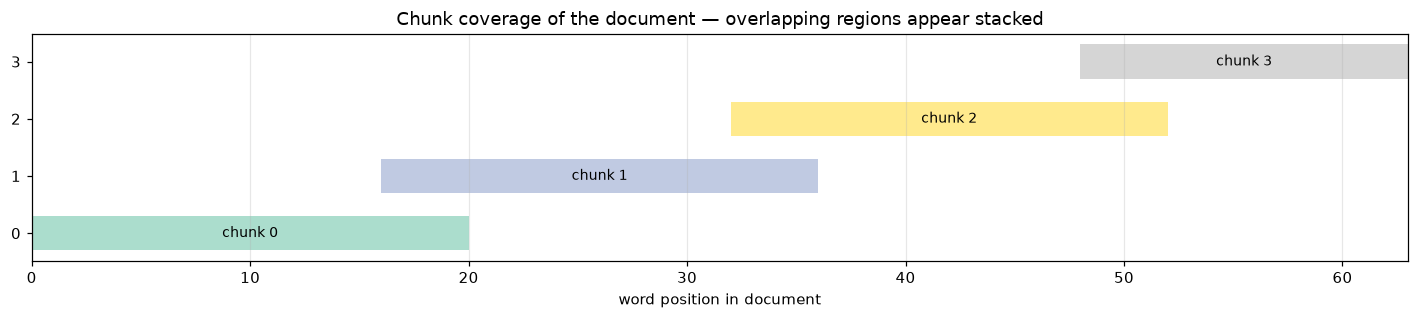

In [ ]:

# Visualize which words belong to which chunk (overlap = darker overlap regions)
words = full_text.split()
fig, ax = plt.subplots(figsize=(13, 3))
colors = plt.cm.Set2(np.linspace(0, 1, len(chunks)))
for ci, c in enumerate(chunks):
    cwords = c.split()
    start = None
    # locate each chunk's word span in the full text (first occurrence of its first 3 words)
    for j in range(len(words) - len(cwords) + 1):
        if words[j:j+3] == cwords[:3]:
            start = j
            break
    ax.barh(ci, len(cwords), left=start, height=0.6, color=colors[ci], alpha=0.55,
            label=f"chunk {ci}")
    ax.text(start + len(cwords)/2, ci, f"chunk {ci}", ha="center", va="center", fontsize=9)
ax.set_yticks(range(len(chunks)))
ax.set_xlabel("word position in document")
ax.set_title("Chunk coverage of the document — overlapping regions appear stacked")
ax.set_xlim(0, len(words))
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


## Key points
- Chunking converts **one long text** into **retrievable units**.
- Overlap guarantees that phrases near boundaries are not cut into unusable pieces.
- There is no magic chunk size; it depends on the document and the model window.

## Interview checkpoint
**Q: What happens if chunks are too small or too large?**
**A:** Too small → missing context, retrieval can return fragments that cannot answer the question.
Too large → diluted topic focus, lower similarity precision, and wasted prompt tokens.

# PART B — The embedding journey: 10 lessons

Everything from here until Section 14 teaches one thing, completely:

> How does the text `"Female employees receive 26 weeks of paid maternity leave."`
> become a vector that lives in a vector database?

The lessons follow the exact chain:

```
1. What is a token?
2. What is a token ID?
3. What is an embedding?
4. What is an embedding matrix?
5. How does a token ID select a vector?
6. Where do embedding values come from?
7. How are embedding parameters learned?
8. How does the Transformer transform token representations?
9. How do we get one final chunk embedding?
10. How does this enter the vector database?
```

Two rules for the rest of the notebook: toy mathematics used to explain a
mechanism is marked "toy example", and values produced by the real model are
marked "actual output". The two are never mixed.

---

## Lesson 1 — What is a token?

**Definition.** A token is the atomic piece of text a model operates on. It is
usually a whole word, but it can also be a number, punctuation, or a fragment of
a word.

**Intuition.** A model does not read characters or whole sentences — it reads a
fixed vocabulary of pieces. Before any mathematics can happen, raw text has to
be chopped into those pieces.

**One word can become several tokens** (a real MiniLM split, shown in the cells
below):

```
"unbelievably"  →  ['un', '##bel', '##ie', '##va', '##bly']
                    └── ## means "continuation of the previous word"
```

---

## Lesson 2 — What is a token ID?

**Definition.** A token ID is an integer index that identifies a token inside
the tokenizer's vocabulary. It is a lookup position — not a semantic value.

**The part everyone trips on:**

```
TEXT          "Female employees receive 26 weeks of paid maternity leave."
   ↓  TOKENIZER   (deterministic rules: lowercase, split, map to vocabulary)
TOKENS        ['female', 'employees', ...]
   ↓  VOCABULARY LOOKUP  (dictionary: token string -> integer position)
TOKEN IDS     [2931, 5126, ...]
```

`"maternity" → 23676` does not mean "23676 = maternity". It means the vocabulary
is an ordered list of 30,522 entries and the string `"maternity"` sits at
position 23676 — like a page number in a dictionary. The ID carries no meaning
by itself; a different tokenizer would produce a different ID.

**Run the next cells.** They use the actual tokenizer of the embedding model
(`sentence-transformers/all-MiniLM-L6-v2`, BERT-style WordPiece, vocab =
30,522). You will see the real tokens, the real IDs, the special tokens, subword
splits, and how to inspect the vocabulary dict yourself.

---

## Lesson 3 — What is an embedding?

**Definition (simple language first).** An embedding is a learned numerical
representation of an input that places semantically related inputs near each
other in a vector space. Similar meaning → similar vector.

**Token ID vs embedding — not the same thing:**

```
TOKEN        "maternity"
   ↓
TOKEN ID     23676                  ← just an identifier / index (a label)
   ↓
EMBEDDING LOOKUP                   ← "go to row 23676 of the learned table"
   ↓
VECTOR       [0.031, -0.082, ...]   ← the numerical representation (the math object)
```

The ID is the address; the embedding is the content. Lesson 9 prints both, with
real values from the real model, side by side.

In [ ]:

from transformers import AutoTokenizer

TOKENIZER_NAME = "sentence-transformers/all-MiniLM-L6-v2"
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)   # downloads the real vocab file

print("ACTUAL MODEL OUTPUT — tokenizer facts")
print("  tokenizer    :", tokenizer.name_or_path)
print("  class        :", type(tokenizer).__name__, "(BERT-style WordPiece tokenizer)")
print("  vocabulary size:", len(tokenizer), "tokens")
print("  special tokens: CLS id =", tokenizer.cls_token_id, "| SEP id =", tokenizer.sep_token_id,
      "| PAD id =", tokenizer.pad_token_id, "| UNK id =", tokenizer.unk_token_id)

ACTUAL MODEL OUTPUT — tokenizer facts
  tokenizer    : sentence-transformers/all-MiniLM-L6-v2
  class        : BertTokenizer (BERT-style WordPiece tokenizer)
  vocabulary size: 30522 tokens
  special tokens: CLS id = 101 | SEP id = 102 | PAD id = 0 | UNK id = 100


In [ ]:

# Tokenize the REAL chunk from our document — no invented values, this prints live output.
text = "Female employees receive 26 weeks of paid maternity leave."

tokens = tokenizer.tokenize(text)                       # string -> token strings
ids    = tokenizer.convert_tokens_to_ids(tokens)        # token strings -> integer IDs

print("ACTUAL OUTPUT — token | token ID")
print(f"{'token':<15} {'id':>6}")
print("-" * 24)
for t, i in zip(tokens, ids):
    print(f"{t!r:<15} {i:>6}")
print("-" * 24)
print(f"{'TOTAL':<15} {len(tokens):>6} tokens")
print()
print("round-trip check  :", tokenizer.convert_tokens_to_string(tokens))
print("decode ids -> text:", tokenizer.decode(ids))

ACTUAL OUTPUT — token | token ID
token               id
------------------------
'female'          2931
'employees'       5126
'receive'         4374
'26'              2656
'weeks'           3134
'of'              1997
'paid'            3825
'maternity'      23676
'leave'           2681
'.'               1012
------------------------
TOTAL               10 tokens

round-trip check  : female employees receive 26 weeks of paid maternity leave.
decode ids -> text: female employees receive 26 weeks of paid maternity leave.


In [ ]:

# How the model ACTUALLY receives the sentence (with special tokens)
encoded = tokenizer(text)                     # adds [CLS] at start and [SEP] at end
print("ACTUAL OUTPUT — tokenizer.__call__ output")
print(json.dumps(encoded, indent=2, default=str))
print()
print("tokens with specials:", tokenizer.convert_ids_to_tokens(encoded["input_ids"]))
print("input_ids          :", encoded["input_ids"])
print("attention_mask     :", encoded["attention_mask"], "  <- 1 = real token, 0 = padding (none needed here)")

ACTUAL OUTPUT — tokenizer.__call__ output
"{'input_ids': [101, 2931, 5126, 4374, 2656, 3134, 1997, 3825, 23676, 2681, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}"

tokens with specials: ['[CLS]', 'female', 'employees', 'receive', '26', 'weeks', 'of', 'paid', 'maternity', 'leave', '.', '[SEP]']
input_ids          : [101, 2931, 5126, 4374, 2656, 3134, 1997, 3825, 23676, 2681, 1012, 102]
attention_mask     : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]   <- 1 = real token, 0 = padding (none needed here)


In [ ]:

# Subword tokenization — one English word can become MULTIPLE tokens
for w in ["maternity", "unbelievably", "paternity", "remotely", "1000"]:
    toks = tokenizer.tokenize(w)
    print(f"{w!r:20} -> {toks}")

'maternity'          -> ['maternity']
'unbelievably'       -> ['un', '##bel', '##ie', '##va', '##bly']
'paternity'          -> ['pat', '##ern', '##ity']
'remotely'           -> ['remotely']
'1000'               -> ['1000']


In [ ]:

# Inspect the vocabulary itself: a plain Python dict {token_string: id}
vocab = tokenizer.get_vocab()
print("ACTUAL OUTPUT — vocabulary peek")
print("  type:", type(vocab), "| size:", len(vocab))
print("  vocab['maternity'] =", vocab.get("maternity", "not a whole token — try subwords"))
print("  vocab['##ably']    =", vocab.get("##ably", "not in vocab"))
print("  vocab['[CLS]']     =", vocab["[CLS]"], " (special token)")
print()
print("  first 5 entries :", list(vocab.items())[:5])
print("  entry #10000    :", list(vocab.items())[10000])

ACTUAL OUTPUT — vocabulary peek
  type: <class 'dict'> | size: 30522
  vocab['maternity'] = 23676
  vocab['##ably']    = 8231
  vocab['[CLS]']     = 101  (special token)

  first 5 entries : [('ए', 1314), ('nairobi', 21124), ('mitochondrial', 23079), ('election', 2602), ('trimmed', 21920)]
  entry #10000    : ('##guchi', 16918)


In [ ]:

# Interactive: type any sentence, see its REAL tokens and IDs
from ipywidgets import interact

@interact(text="Female employees receive 26 weeks of paid maternity leave.")
def show_tokens(text):
    ts  = tokenizer.tokenize(text)
    ids = tokenizer.convert_tokens_to_ids(ts)
    if not ts:
        print("(no tokens)")
        return
    for t, i in zip(ts, ids):
        print(f"{t!r:<20} -> {i}")
    print(f"\n{len(ts)} tokens | decode check:", tokenizer.convert_tokens_to_string(ts))

'female'             -> 2931
'employees'          -> 5126
'receive'            -> 4374
'26'                 -> 2656
'weeks'              -> 3134
'of'                 -> 1997
'paid'               -> 3825
'maternity'          -> 23676
'leave'              -> 2681
'.'                  -> 1012

10 tokens | decode check: female employees receive 26 weeks of paid maternity leave.
interactive(children=(Text(value='Female employees receive 26 weeks of paid maternity leave.', description='text'), Output()), _dom_classes=('widget-interact',))


## Lessons 1–2 — Key points

- Token ≠ necessarily word; token ID ≠ meaning; token ID = vocabulary index.
- Tokenization is deterministic: same text → same IDs, on any machine.
- IDs are meaningless across models — each tokenizer has its own vocabulary.

**Interview question: What is a token ID?**
**A:** An integer index that identifies a token inside the tokenizer's fixed vocabulary.
It is used to look up the token's learned embedding vector and has no semantic meaning by itself.

## Lesson 4 — What is an embedding matrix?

**Definition.** The embedding matrix `E` is a learned table:

- **rows = vocabulary tokens**
- **columns = embedding dimensions** (learned numbers per token)

**toy example — FOR UNDERSTANDING THE MATHEMATICS ONLY** (vocab = 5, dim = 3):

```
              d1     d2     d3
E =  row 0  [ 0.0,   0.0,   0.0 ]   <- "<PAD>"
     row 1  [ 1.1,   0.3,  -0.2 ]   <- "cat"
     row 2  [ 1.0,  -0.1,   0.4 ]   <- "dog"
     row 3  [ 0.4,   0.8,  -0.5 ]   <- "female"
     row 4  [ 0.2,   0.6,   0.9 ]   <- "maternity"
```

The cell below builds this toy matrix in NumPy. The heatmap after it highlights the row
a token ID selects. The REAL MiniLM matrix has the same structure, just 30,522 × 384.

In [ ]:

import numpy as np

# TOY embedding matrix: 5 vocabulary rows x 3 dimensions (hand-made numbers!)
TOY_VOCAB = ["<PAD>", "cat", "dog", "female", "maternity"]
TOY_E = np.array([
    [0.0,  0.0,  0.0],   # row 0 = <PAD>
    [1.1,  0.3, -0.2],   # row 1 = cat
    [1.0, -0.1,  0.4],   # row 2 = dog
    [0.4,  0.8, -0.5],   # row 3 = female
    [0.2,  0.6,  0.9],   # row 4 = maternity
])
print("TOY EXAMPLE ONLY — E shape:", TOY_E.shape, "(vocab=5 rows, dim=3 cols)")

token_id = 4   # "maternity" in this toy vocab
print(f"\n1) Direct row lookup:  E[{token_id}] = {TOY_E[token_id]}")

one_hot = np.zeros(len(TOY_VOCAB))
one_hot[token_id] = 1.0
print(f"2) one_hot({token_id}) = {one_hot}")

selected = one_hot @ TOY_E          # (1,5) x (5,3) -> (1,3)
print(f"3) one_hot @ E        = {selected}")

assert np.allclose(selected, TOY_E[token_id]), "the two ways MUST agree"
print("\nBoth ways produce the SAME vector (they are mathematically identical).")

TOY EXAMPLE ONLY — E shape: (5, 3) (vocab=5 rows, dim=3 cols)

1) Direct row lookup:  E[4] = [0.2 0.6 0.9]
2) one_hot(4) = [0. 0. 0. 0. 1.]
3) one_hot @ E        = [0.2 0.6 0.9]

Both ways produce the SAME vector (they are mathematically identical).


In [ ]:
# EVERY multiplication, written out — nothing skipped (toy matrix from the cell above)
print("one_hot(4) = [0, 0, 0, 0, 1]\n")
print("one_hot(4) × E  =  one row-sum at a time:")
for r in range(TOY_E.shape[0]):
    weight = one_hot[r]
    print(f"   {weight} · row{r}  =  {weight} · {TOY_E[r].tolist()}  =  {(weight * TOY_E[r]).tolist()}")
result = one_hot @ TOY_E
print(f"\n   sum of all 5 rows      =  {result.tolist()}")
print(f"   direct lookup E[4]      =  {TOY_E[4].tolist()}")
print("\n-> Only the row multiplied by 1 survives; every other row is multiplied by 0")
print("   and disappears. That is ALL a token ID does: it selects one row.")

one_hot(4) = [0, 0, 0, 0, 1]

one_hot(4) × E  =  one row-sum at a time:
   0.0 · row0  =  0.0 · [0.0, 0.0, 0.0]  =  [0.0, 0.0, 0.0]
   0.0 · row1  =  0.0 · [1.1, 0.3, -0.2]  =  [0.0, 0.0, -0.0]
   0.0 · row2  =  0.0 · [1.0, -0.1, 0.4]  =  [0.0, -0.0, 0.0]
   0.0 · row3  =  0.0 · [0.4, 0.8, -0.5]  =  [0.0, 0.0, -0.0]
   1.0 · row4  =  1.0 · [0.2, 0.6, 0.9]  =  [0.2, 0.6, 0.9]

   sum of all 5 rows      =  [0.2, 0.6, 0.9]
   direct lookup E[4]      =  [0.2, 0.6, 0.9]

-> Only the row multiplied by 1 survives; every other row is multiplied by 0
   and disappears. That is ALL a token ID does: it selects one row.


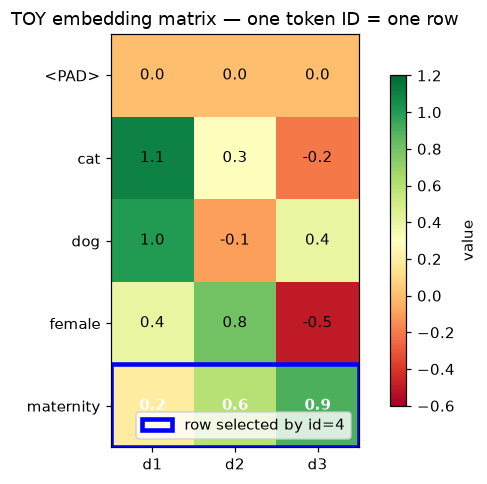

In [ ]:

# Visualize the lookup: highlight the selected row of the embedding matrix
fig, ax = plt.subplots(figsize=(6, 4.5))
im = ax.imshow(TOY_E, cmap="RdYlGn", vmin=-0.6, vmax=1.2)
ax.set_xticks(range(3)); ax.set_xticklabels(["d1", "d2", "d3"])
ax.set_yticks(range(5)); ax.set_yticklabels(TOY_VOCAB)
for r in range(5):
    for c in range(3):
        ax.text(c, r, f"{TOY_E[r, c]:.1f}", ha="center", va="center",
                fontweight="bold" if r == token_id else "normal",
                color="black" if r != token_id else "white")
ax.add_patch(plt.Rectangle((-0.5, token_id - 0.5), 3, 1, fill=False,
                           edgecolor="blue", lw=3, label=f"row selected by id={token_id}"))
ax.set_title("TOY embedding matrix — one token ID = one row")
ax.legend(loc="lower right")
plt.colorbar(im, ax=ax, shrink=0.8, label="value")
plt.tight_layout()
plt.show()

## Lesson 5 — Key points

- "Embedding a token" = selecting row `token_id` of `E`. Nothing more.
- `one_hot(token_id) × E` is the same operation written as matrix multiplication:
  the one-hot "kills" every row except the selected one (watch the arithmetic in the cell
  above — every row multiplication is printed).
- Real libraries use efficient row lookup; the one-hot view is the mathematical
  definition that makes the gradient math clean.

**Interview question: Can we just use the token ID as the embedding?**
**A:** No. The ID is an arbitrary position. Embedding rows are *learned* so that tokens
with related meanings have related vectors — the ID alone carries no such information.

---

## Lesson 6 — Where do d1, d2, d3 come from? (the most important question)

> "If d1 = 0.17, d2 = −0.32 and d3 = 0.81 — **who decided these values?**"

Short answer: **nobody decided them.** They are parameters. They start as random numbers
and are *improved by training*:

```
INITIAL EMBEDDING MATRIX   (random numbers)
        ↓  FORWARD PASS    (look up rows, compute a prediction)
OUTPUT / PREDICTION
        ↓  LOSS            (a scalar: how wrong was the prediction?)
LOSS
        ↓  BACKPROPAGATION (chain rule: how much did each number in E contribute?)
GRADIENT  ∂L/∂E
        ↓  GRADIENT DESCENT
UPDATED EMBEDDING MATRIX
```

If the initial matrix is random, the trained matrix is random + corrections — the
corrections are chosen by the data, not by a human.

## Lesson 7 — How are embedding parameters learned? (real gradient math)

**The update equation, symbol by symbol:**

```
E_new  =  E_old  −  α · ∂L/∂E

E      : the embedding matrix (here: a 5×3 table) — the parameters we are learning
L      : the loss — a scalar measuring how wrong the prediction is (MSE in the cell below)
∂L/∂E  : the gradient — for every entry of E: "if I nudge this number, how much does L change?"
α      : the learning rate — how big a step we take per update (0.1 below)
−      : we move AGAINST the gradient (downhill, toward smaller loss)
```

**TOY TRAINING EXAMPLE — REAL MATHEMATICS, NOT THE TRAINING PROCESS OF MiniLM.**
The cell below trains a tiny 5×3 table with **real PyTorch autograd**: forward pass, MSE
loss, `loss.backward()`, then the update applied by hand. It prints the initial matrix,
the forward output, the loss, the gradient `∂L/∂E`, the learning rate, and the updated
matrix — and verifies `E_after == E_before − α·∂L/∂E`.

MiniLM's 30,522×384 table was trained by the same mechanism, at enormous scale. We cannot
reconstruct its training from a single inference — but the mathematics is identical.

In [ ]:

import torch

# TOY EXAMPLE — 5-token vocab, 3-dim embeddings. Values are random init + REAL gradient math.
torch.manual_seed(0)
embed = torch.nn.Embedding(num_embeddings=5, embedding_dim=3)   # the learned table E
E_before = embed.weight.detach().clone()
print("TOY — initial E (random parameters):\n", E_before)

# "Training example": input ids [4, 1, 2]  (toy: maternity, cat, dog)
# target: a toy label vector we pretend is correct
ids    = torch.tensor([4, 1, 2])
target = torch.tensor([0.5, -0.2, 0.9])   # toy label, NOT a real task

# ---- forward pass ----
x    = embed(ids)              # (3, 3): row lookup for each id
pred = x.mean(dim=0)           # (3,): mean-pool the 3 token vectors
loss = ((pred - target) ** 2).mean()     # MSE loss: mean of squared errors

print(f"\nforward:  ids={ids.tolist()} -> pooled prediction {pred.tolist()}")
print(f"loss    : {loss.item():.4f}  (MSE)")

# ---- backward pass: compute dL/dE ----
loss.backward()
grad = embed.weight.grad      # same shape as E: (5, 3)
print("\ngradient dL/dE (real autograd output):\n", grad)
print("\nNOTE: only rows that were USED in the forward pass (4,1,2) have non-zero gradients!")

# ---- gradient descent: E_new = E_old - lr * grad ----
lr = 0.1
with torch.no_grad():
    embed.weight -= lr * grad          # THE parameter update, by hand
E_after = embed.weight.detach().clone()

expected = E_before - lr * grad
print("\nupdated E (real):\n", E_after)
print("\nE_after == E_before - lr * grad ?", torch.allclose(E_after, expected))

TOY — initial E (random parameters):
 tensor([[ 1.5410, -0.2934, -2.1788],
        [ 0.5684, -1.0845, -1.3986],
        [ 0.4033,  0.8380, -0.7193],
        [-0.4033, -0.5966,  0.1820],
        [-0.8567,  1.1006, -1.0712]])

forward:  ids=[4, 1, 2] -> pooled prediction [0.038367826491594315, 0.28470271825790405, -1.0630134344100952]
loss    : 1.4338  (MSE)

gradient dL/dE (real autograd output):
 tensor([[ 0.0000,  0.0000,  0.0000],
        [-0.1026,  0.1077, -0.4362],
        [-0.1026,  0.1077, -0.4362],
        [ 0.0000,  0.0000,  0.0000],
        [-0.1026,  0.1077, -0.4362]])

NOTE: only rows that were USED in the forward pass (4,1,2) have non-zero gradients!

updated E (real):
 tensor([[ 1.5410, -0.2934, -2.1788],
        [ 0.5787, -1.0953, -1.3550],
        [ 0.4136,  0.8273, -0.6756],
        [-0.4033, -0.5966,  0.1820],
        [-0.8464,  1.0898, -1.0276]])

E_after == E_before - lr * grad ? True


In [ ]:
# The update rule, symbol by symbol (values computed in the cell above)
print("learning rate      α   =", lr)
print("gradient        ∂L/∂E   =\n", grad)
print()
print("E_new = E_old − α · ∂L/∂E")
print("      = (E_before) − 0.1 · (gradient)")
print("      = (E_after)         <- verified with torch.allclose above")
print()
print("→ every number in the table moved a little bit AGAINST its gradient:")
print("→ the loss was 1.4338 before the step; the same rule, applied millions of")
print("  times on real data, is how MiniLM's 30,522 × 384 table got its values.")

learning rate      α   = 0.1
gradient        ∂L/∂E   =
 tensor([[ 0.0000,  0.0000,  0.0000],
        [-0.1026,  0.1077, -0.4362],
        [-0.1026,  0.1077, -0.4362],
        [ 0.0000,  0.0000,  0.0000],
        [-0.1026,  0.1077, -0.4362]])

E_new = E_old − α · ∂L/∂E
      = (E_before) − 0.1 · (gradient)
      = (E_after)         <- verified with torch.allclose above

→ every number in the table moved a little bit AGAINST its gradient:
→ the loss was 1.4338 before the step; the same rule, applied millions of
  times on real data, is how MiniLM's 30,522 × 384 table got its values.


## Lesson 7 — Key points

- Embedding values are **learned parameters**, updated by gradient descent.
- Only rows actually used in the forward pass get gradient (the printed gradient is zero
  for unused rows) — that's why the update is cheap and sparse.
- Distributed representations: no dimension is labelled with a concept. Meaning lives in
  the **pattern across all dimensions**, learned jointly with the rest of the model.

**Interview question: Who chooses the numbers inside an embedding vector?**
**A:** No one directly. They are learned model parameters optimized by gradient descent so
that the vectors support the training objective. That is why similar words end up with
similar vectors even though no dimension was ever labelled by a human.

---

## Lesson 8 — How does the Transformer transform token representations?

**Definition.** Self-attention lets each token gather information from every other
token in the sequence, weighted by how relevant they are to each other. The result is a
**contextual representation** — the same word gets a different vector depending on its
sentence.

**The chain inside the real model:**

```
TOKEN VECTORS            (T, 384)   <- static, dictionary-like: no context yet
   ↓  12 Transformer layers, each: self-attention + feed-forward
CONTEXTUAL REPRESENTATIONS (T, 384)  <- same shape, but each token now "sees" the others
```

## The self-attention equation (toy calculation below)

```
Q = X·W_Q        queries:  "what am I looking for?"
K = X·W_K        keys:     "what do I contain?"
V = X·W_V        values:   "what information do I offer?"

Attention(Q, K, V)  =  softmax( Q·Kᵀ / √d_k ) · V
```

1. `Q·Kᵀ` → a compatibility score between every pair of tokens
2. `/√d_k` → scaling that keeps the softmax well-behaved
3. `softmax` → each row becomes weights that sum to 1
4. `·V` → each output row is a weighted average of ALL value vectors

**TOY ATTENTION CALCULATION FOR LEARNING — NOT REAL MODEL OUTPUT.** 3 tokens,
`d_model = 4`, `d_k = 2` — the cell below prints Q, K, V, the scaled scores, the softmax
weights and the weighted sum, one step at a time. A real MiniLM does this with 12 layers ×
12 heads × 384 dimensions.

In [ ]:

# TOY ATTENTION — hand-built with NumPy, every step printed. NOT real model output.
rng = np.random.default_rng(42)
d_model, d_k, d_v = 4, 2, 2

X = np.array([                       # 3 toy "token vectors" (3 tokens, 4 dims each)
    [1.0, 0.0, 1.0, 0.0],            # token 0
    [0.0, 1.0, 0.0, 1.0],            # token 1
    [1.0, 1.0, 0.0, 0.0],            # token 2
])
W_Q = rng.normal(0, 1, (d_model, d_k))
W_K = rng.normal(0, 1, (d_model, d_k))
W_V = rng.normal(0, 1, (d_model, d_v))

Q = X @ W_Q     # (3,2)
K = X @ W_K     # (3,2)
V = X @ W_V     # (3,2)
print("Q = X·W_Q:\n", np.round(Q, 3))
print("K = X·W_K:\n", np.round(K, 3))
print("V = X·W_V:\n", np.round(V, 3))

scores = (Q @ K.T) / np.sqrt(d_k)    # (3,3) compatibility matrix, scaled
print("\nQ·Kᵀ / √d_k  (scaled scores):\n", np.round(scores, 3))

def softmax_rows(a):
    e = np.exp(a - a.max(axis=1, keepdims=True))   # subtract max for numerical stability
    return e / e.sum(axis=1, keepdims=True)

A = softmax_rows(scores)             # (3,3) attention weights, rows sum to 1
print("\nattention weights A = softmax(scores):\n", np.round(A, 3))
print("   row sums:", A.sum(axis=1), " (each row sums to 1 -> a weighted average)")

out = A @ V                          # (3,3)x(3,2) -> (3,2)
print("\noutput = A·V  (each row = weighted sum of ALL value vectors):\n", np.round(out, 3))

Q = X·W_Q:
 [[-1.646 -2.342]
 [ 0.878  0.624]
 [ 1.055 -0.099]]
K = X·W_K:
 [[ 0.049  0.274]
 [ 1.347 -0.082]
 [ 0.863 -0.075]]
V = X·W_V:
 [[ 0.184 -1.64 ]
 [ 2.101 -0.204]
 [ 1.247 -1.009]]

Q·Kᵀ / √d_k  (scaled scores):
 [[-0.511 -1.433 -0.88 ]
 [ 0.152  0.801  0.502]
 [ 0.017  1.011  0.649]]

attention weights A = softmax(scores):
 [[0.478 0.19  0.331]
 [0.231 0.442 0.328]
 [0.179 0.484 0.337]]
   row sums: [1. 1. 1.]  (each row sums to 1 -> a weighted average)

output = A·V  (each row = weighted sum of ALL value vectors):
 [[ 0.901 -1.158]
 [ 1.379 -0.799]
 [ 1.47  -0.733]]


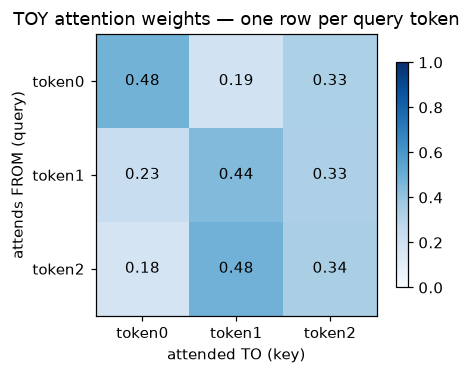

In [ ]:

# Visualize the toy attention matrix
fig, ax = plt.subplots(figsize=(4.5, 3.5))
im = ax.imshow(A, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(["token0", "token1", "token2"])
ax.set_yticklabels(["token0", "token1", "token2"])
ax.set_xlabel("attended TO (key)")
ax.set_ylabel("attends FROM (query)")
for r in range(3):
    for c in range(3):
        ax.text(c, r, f"{A[r, c]:.2f}", ha="center", va="center")
ax.set_title("TOY attention weights — one row per query token")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## Lesson 8 — Key points

- Attention output for token *i* = weighted average of all tokens' values, weighted by
  compatibility. That is what makes representations contextual.
- Toy math (3×2 matrices) and the real model (12 layers × 12 heads × 384-d) use the exact
  same equation.

**Interview question: What are Q, K, V in self-attention?**
**A:** Learned linear projections of the input. Queries express "what I'm looking for",
keys "what I contain", values "what I communicate". Compatibility scores (Q·Kᵀ) are
softmax-normalized into weights that average the values.

---

## Lesson 9 — How do we get one final chunk embedding? (the real model)

Now we leave toy land for good. The model below is
**`sentence-transformers/all-MiniLM-L6-v2`** — 12 layers, 384-dimensional output,
30,522-token vocabulary (the tokenizer you already used), mean pooling. Every value in
this lesson is **REAL MODEL OUTPUT**, produced at runtime — nothing invented.

## The real chain for our chunk

```
"Female employees receive 26 weeks of paid maternity leave."
   ↓  ACTUAL TOKENIZER      (Lesson 2 — real tokens, real IDs, already printed)
ACTUAL TOKEN IDS            [2931, 5126, 4374, 2656, 3134, 1997, 3825, 23676, 2681, 1012]
   ↓  ACTUAL MODEL          embedding lookup -> 12 Transformer layers
CONTEXTUAL TOKEN VECTORS    (1, 10, 384)
   ↓  POOLING               mean over the 10 tokens -> L2-normalize
ACTUAL FINAL EMBEDDING      (384,)
```

Run the next two cells: the model facts, then the real embedding with its shape, its
first 10 values and its norm.

In [ ]:

from sentence_transformers import SentenceTransformer

MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
model = SentenceTransformer(MODEL_NAME)      # first call downloads the weights

print("ACTUAL MODEL OUTPUT — model facts")
# sentence-transformers >=5 renamed this getter; support both names
_dim_fn = getattr(model, "get_embedding_dimension", None) or model.get_sentence_embedding_dimension
print("  model                     :", MODEL_NAME)
print("  sentence embedding dim    :", _dim_fn())
print(model)   # sentence-transformers prints its own architecture summary (layers, pooling)

ACTUAL MODEL OUTPUT — model facts
  model                     : sentence-transformers/all-MiniLM-L6-v2
  sentence embedding dim    : 384
SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
  (1): Pooling({'embedding_dimension': 384, 'pooling_mode': 'mean', 'include_prompt': True})
  (2): Normalize({'module_input_name': 'sentence_embedding', 'module_output_name': 'sentence_embedding'})
)


In [ ]:

# REAL embedding of the REAL chunk. Values below are produced by the model AT RUNTIME.
text = "Female employees receive 26 weeks of paid maternity leave."
emb = model.encode(text, normalize_embeddings=True)     # (384,) L2-normalized

print("ACTUAL MODEL OUTPUT")
print("  input text       :", text)
print("  embedding shape  :", emb.shape)
print("  first 10 values  :", np.round(emb[:10], 6))
print("  L2 norm          :", round(float(np.linalg.norm(emb)), 6),
      "  (1.0 because we normalized — direction only, magnitude removed)")
print("  min / max        :", round(float(emb.min()), 4), "/", round(float(emb.max()), 4))
print()
print("These 384 numbers ARE the sentence, as far as the vector space is concerned.")
print("Dimension #7 does NOT mean 'maternity'. Meaning is distributed across all 384.")

ACTUAL MODEL OUTPUT
  input text       : Female employees receive 26 weeks of paid maternity leave.
  embedding shape  : (384,)
  first 10 values  : [ 0.014689 -0.028578 -0.040334  0.053082  0.044691  0.086009 -0.082365
 -0.062886 -0.048324  0.037371]
  L2 norm          : 1.0   (1.0 because we normalized — direction only, magnitude removed)
  min / max        : -0.1608 / 0.1532

These 384 numbers ARE the sentence, as far as the vector space is concerned.
Dimension #7 does NOT mean 'maternity'. Meaning is distributed across all 384.


## The three things — do not confuse them

1. **Token ID** — e.g. `23676` — an index/label. No meaning.
2. **Token embedding** — the real learned 384-d row of MiniLM's embedding table
   for that token. One word's static, context-free vector.
3. **Final chunk embedding** — the real 384-d vector for the whole sentence,
   after attention and pooling.

The next cell prints all three side by side, with real values.

## Why no dimension means one concept

Wrong mental model: *"d1 = female, d2 = maternity, d3 = leave"*. Correct model:
semantic information is distributed — many dimensions jointly encode useful
information:

```
"maternity"  "female"  "leave"  "26 weeks"
      ↓  distributed numerical representation
many dimensions jointly encode the meaning — no single dimension is a concept
```

The cell after that visualises four real token vectors from MiniLM's embedding
table: a heatmap of their dimensions and their pairwise similarities, and then
the same words after attention. The static dictionary entries alone are crude
("maternity" vs "leave" starts at 0.14); context is what turns them into the
phrase "maternity leave" (0.57 after the 12 layers). No single dimension is
ever the concept.

In [ ]:
# THE THREE THINGS, real values side by side — do not confuse them
tok_id = tokenizer.convert_tokens_to_ids("maternity")

with torch.no_grad():
    emb_table = model[0].auto_model.embeddings.word_embeddings.weight   # (30522, 384) REAL table
    token_vec = emb_table[tok_id].numpy()          # 2) TOKEN EMBEDDING: real learned row

chunk_vec = emb                                     # 3) FINAL CHUNK EMBEDDING (from Lesson 9)

print("1) TOKEN ID")
print("   'maternity' ->", tok_id)
print("   -> an index. It is NOT a number with meaning.\n")
print("2) TOKEN EMBEDDING  (one word's static vector, row", tok_id, "of the real table, shape",
      token_vec.shape, ")")
print("   ", np.round(token_vec[:8], 5), "...\n")
print("3) FINAL CHUNK EMBEDDING  (the whole sentence, shape", chunk_vec.shape, ")")
print("   ", np.round(chunk_vec[:8], 5), "...\n")
print("-> 1 is a label. 2 is ONE word's dictionary entry (no context).")
print("-> 3 summarizes the WHOLE sentence: 10 token vectors -> attention -> mean pooling.")

1) TOKEN ID
   'maternity' -> 23676
   -> an index. It is NOT a number with meaning.

2) TOKEN EMBEDDING  (one word's static vector, row 23676 of the real table, shape (384,) )
    [-0.05258  0.06968  0.06062 -0.06679  0.07221  0.04101 -0.008   -0.01068] ...

3) FINAL CHUNK EMBEDDING  (the whole sentence, shape (384,) )
    [ 0.01469 -0.02858 -0.04033  0.05308  0.04469  0.08601 -0.08237 -0.06289] ...

-> 1 is a label. 2 is ONE word's dictionary entry (no context).
-> 3 summarizes the WHOLE sentence: 10 token vectors -> attention -> mean pooling.


REAL OUTPUT — static token vectors (dictionary entries, no context yet)
   pairwise cosine similarities:
    maternity [np.float32(1.0), np.float32(0.176), np.float32(0.142), np.float32(0.204)]
    female    [np.float32(0.176), np.float32(1.0), np.float32(0.059), np.float32(0.026)]
    leave     [np.float32(0.142), np.float32(0.059), np.float32(1.0), np.float32(0.002)]
    weeks     [np.float32(0.204), np.float32(0.026), np.float32(0.002), np.float32(1.0)]
   -> 'maternity' vs 'leave' is only 0.142 here: the dictionary entry
      alone does NOT know that 'maternity leave' is a phrase.

REAL OUTPUT — AFTER 12 attention layers, inside the real sentence:
   contextual 'maternity' vs 'leave' similarity = 0.570
   -> context is what turns two dictionary entries into the phrase 'maternity leave'.

   And NO single dimension is the 'maternity dimension':
   dimension 0 alone holds all four words at once: [-0.0526  0.0567 -0.0631  0.0193]
   Meaning is distributed across the whole 384-d patte

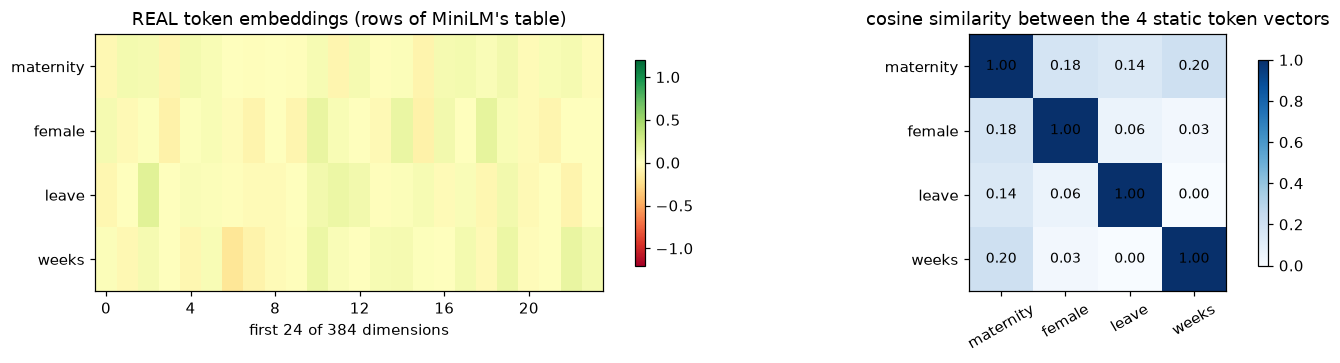

In [ ]:
# Distributed representations: 4 real token vectors from MiniLM's embedding table
from sklearn.metrics.pairwise import cosine_similarity

words = ["maternity", "female", "leave", "weeks"]
word_ids = tokenizer.convert_tokens_to_ids(words)
with torch.no_grad():
    word_vecs = emb_table[word_ids].numpy()          # (4, 384) REAL static token vectors

sims = cosine_similarity(word_vecs)                  # how close BEFORE any context?

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.4))
im = axes[0].imshow(word_vecs[:, :24], cmap="RdYlGn", vmin=-1.2, vmax=1.2, aspect="auto")
axes[0].set_xticks(range(0, 24, 4))
axes[0].set_xlabel("first 24 of 384 dimensions")
axes[0].set_yticks(range(4)); axes[0].set_yticklabels(words)
axes[0].set_title("REAL token embeddings (rows of MiniLM's table)")
plt.colorbar(im, ax=axes[0], shrink=0.8)
im2 = axes[1].imshow(sims, cmap="Blues", vmin=0, vmax=1)
axes[1].set_xticks(range(4)); axes[1].set_xticklabels(words, rotation=30)
axes[1].set_yticks(range(4)); axes[1].set_yticklabels(words)
axes[1].set_title("cosine similarity between the 4 static token vectors")
for r in range(4):
    for c in range(4):
        axes[1].text(c, r, f"{sims[r, c]:.2f}", ha="center", va="center", fontsize=9)
plt.colorbar(im2, ax=axes[1], shrink=0.8)
plt.tight_layout(); plt.show()

print("REAL OUTPUT — static token vectors (dictionary entries, no context yet)")
print("   pairwise cosine similarities:")
for a in range(4):
    print("   ", words[a].ljust(9), [round(sims[a, b], 3) for b in range(4)])
print("   -> 'maternity' vs 'leave' is only", round(sims[0, 2], 3), "here: the dictionary entry")
print("      alone does NOT know that 'maternity leave' is a phrase.")

# ---- after the Transformer: do the SAME two words become related? ----
enc = tokenizer(text, return_tensors="pt")
with torch.no_grad():
    out = model[0].auto_model(**enc)
ctx = out.last_hidden_state[0].numpy()               # (T, 384) contextual vectors
toks = tokenizer.convert_ids_to_tokens(enc["input_ids"][0])
i_mat, i_leave = toks.index("maternity"), toks.index("leave")
ctx_sim = cosine_similarity([ctx[i_mat]], [ctx[i_leave]])[0, 0]
print(f"\nREAL OUTPUT — AFTER 12 attention layers, inside the real sentence:")
print(f"   contextual 'maternity' vs 'leave' similarity = {ctx_sim:.3f}")
print("   -> context is what turns two dictionary entries into the phrase 'maternity leave'.")
print()
print("   And NO single dimension is the 'maternity dimension':")
print("   dimension 0 alone holds all four words at once:", np.round(word_vecs[:, 0], 4))
print("   Meaning is distributed across the whole 384-d pattern.")

## Lesson 9 (continued) — Pooling: token vectors → one vector

**Definition.** The Transformer outputs one 384-d vector **per token**. Retrieval needs
**one** vector for the whole chunk. **Pooling** summarizes the token vectors into a single
fixed-size vector. MiniLM uses **mean pooling** (average over the real tokens, ignore
padding) followed by **L2 normalization**.

```
token representations  (10, 384)
     ↓  mean over the 10 tokens (attention mask ignores padding)
one vector             (384,)
     ↓  L2 normalization   v / ‖v‖
final chunk embedding  (384,)   <- exactly what model.encode() returns
```

The next cell **proves** this: it runs the model's insides by hand (same tokenizer,
same Transformer weights) and compares with `model.encode()` — they match to ~1e-8.

In [ ]:

# ACTUAL MODEL OUTPUT — verify mean pooling against model.encode()
encoded = tokenizer(text, return_tensors="pt")          # tokens -> ids + mask (Section 4)
print("input ids      :", encoded["input_ids"].tolist())
print("attention mask :", encoded["attention_mask"].tolist(), "  <- 1 = real token")

with torch.no_grad():
    outputs = model[0].auto_model(**encoded)            # run the REAL Transformer
token_vecs = outputs.last_hidden_state                   # (1, T, 384) contextual vectors
print("\nlast_hidden_state shape:", tuple(token_vecs.shape),
      "= (batch=1, tokens=T, dim=384)")
print("   first 3 dims of the 'female' token vector:", np.round(token_vecs[0, 1, :3].numpy(), 4))

# ---- mean pooling, by hand ----
mask      = encoded["attention_mask"].unsqueeze(-1).float()   # (1, T, 1)
summed    = (token_vecs * mask).sum(dim=1)                    # (1, 384) sum of real tokens
counts    = mask.sum(dim=1)                                   # (1, 1)   number of real tokens
mean_vec  = summed / counts                                   # (1, 384) the average
manual    = mean_vec / mean_vec.norm(dim=1, keepdim=True)     # L2-normalize, like encode()

real = model.encode(text, normalize_embeddings=True)          # what the library returns
print("\nhand-made mean-pooled vector == model.encode() output ?",
      np.allclose(manual[0].numpy(), real, atol=1e-5))
print("   max abs difference:", float(np.abs(manual[0].numpy() - real).max()))

input ids      : [[101, 2931, 5126, 4374, 2656, 3134, 1997, 3825, 23676, 2681, 1012, 102]]
attention mask : [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]   <- 1 = real token

last_hidden_state shape: (1, 12, 384) = (batch=1, tokens=T, dim=384)
   first 3 dims of the 'female' token vector: [ 0.6782 -0.6797 -0.6272]

hand-made mean-pooled vector == model.encode() output ? True
   max abs difference: 1.4901161193847656e-08


In [ ]:

# Bonus: why mean pooling (and not just the [CLS] token)?
cls_vec = token_vecs[0, 0]                                   # vector of the [CLS] token
from sklearn.metrics.pairwise import cosine_similarity
sim = cosine_similarity(manual[0].numpy().reshape(1, -1), cls_vec.numpy().reshape(1, -1))[0, 0]
print("ACTUAL OUTPUT")
print("  cosine similarity between mean-pooled vector and raw [CLS] vector:", round(float(sim), 4))
print("  -> MiniLM was TRAINED to use the mean of all tokens, not the [CLS] token,")
print("     so that is what sentence-transformers uses as pooling.")

ACTUAL OUTPUT
  cosine similarity between mean-pooled vector and raw [CLS] vector: 0.5258
  -> MiniLM was TRAINED to use the mean of all tokens, not the [CLS] token,
     so that is what sentence-transformers uses as pooling.


## Lesson 9 — Key points

- Pooling turns a variable-length sequence of token vectors into one fixed-size vector.
- MiniLM = mean over real tokens + L2 normalization. We reproduced `model.encode()` by
  hand, so we know exactly what the library does.
- Pooling choice matters (mean / CLS / max); each model is trained for its own.

**Interview question: Why do we need pooling in sentence embedding models?**
**A:** The Transformer produces a vector per token; retrieval needs one vector per chunk.
Pooling aggregates the token vectors into a single fixed-size embedding.

---

## VECTOR SPACE — similar meaning = close directions

A vector is a point/direction in mathematical space. Our real vectors live in **384
dimensions** — impossible to draw directly — so the next cells project them to 2D with
**PCA for visualization only**. The true geometry (and all retrieval decisions) live in
the full 384-d space.

## Embed our 5 real policy chunks and project them to 2D

> The 2D plot is a **projection** of the high-dimensional embeddings; it is NOT the
> original embedding space. Distances in 2D are only approximate.

ACTUAL OUTPUT — embeddings shape: (5, 384) (5 chunks x 384 dims)
variance kept by 2 PCs: 0.652  (of the original 384-d information)


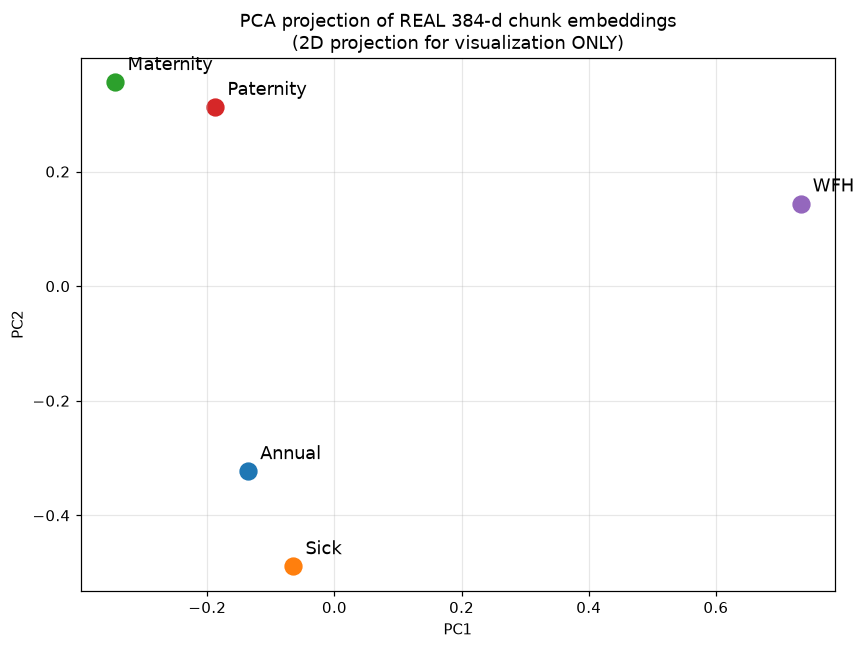

In [ ]:

# The 5 topical chunks of our leave policy (real text from the PDF)
topic_chunks = [
    "Employees receive 18 days of annual leave per year.",
    "Employees receive 10 days of paid sick leave per year.",
    "Female employees receive 26 weeks of paid maternity leave.",
    "Employees receive 7 days of paid paternity leave.",
    "Employees may work remotely up to 2 days per week with manager approval.",
]

emb5 = model.encode(topic_chunks, normalize_embeddings=True)   # (5, 384) REAL embeddings
print("ACTUAL OUTPUT — embeddings shape:", emb5.shape, "(5 chunks x 384 dims)")

from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=0)
xy = pca.fit_transform(emb5)                                   # (5, 2) projection

labels = ["Annual", "Sick", "Maternity", "Paternity", "WFH"]
fig, ax = plt.subplots(figsize=(8, 6))
for (x, y), lab, vec in zip(xy, labels, emb5):
    ax.scatter(x, y, s=120)
    ax.annotate(lab, (x, y), textcoords="offset points", xytext=(8, 8), fontsize=12)
    # also show the 3 nearest neighbours in TRUE 384-d space for one point of reference
ax.set_title("PCA projection of REAL 384-d chunk embeddings\n(2D projection for visualization ONLY)")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("variance kept by 2 PCs:", round(float(pca.explained_variance_ratio_.sum()), 4),
      " (of the original 384-d information)")

In [ ]:

# True-space check: nearest neighbour of each chunk in the REAL 384-d space
sim_matrix = cosine_similarity(emb5)
for i, lab in enumerate(labels):
    order = np.argsort(-sim_matrix[i])
    nn = [labels[j] for j in order if j != i][:2]
    print(f"  {lab:<10} closest to: {nn}   (cosine sims {[round(sim_matrix[i, j], 3) for j in order if j != i][:2]})")

  Annual     closest to: ['Sick', 'Maternity']   (cosine sims [np.float32(0.68), np.float32(0.562)])
  Sick       closest to: ['Annual', 'Paternity']   (cosine sims [np.float32(0.68), np.float32(0.519)])
  Maternity  closest to: ['Paternity', 'Annual']   (cosine sims [np.float32(0.611), np.float32(0.562)])
  Paternity  closest to: ['Maternity', 'Annual']   (cosine sims [np.float32(0.611), np.float32(0.561)])
  WFH        closest to: ['Annual', 'Paternity']   (cosine sims [np.float32(0.425), np.float32(0.414)])


## Vector space — Key points

- Similar meaning → nearby direction (Maternity is closest to Paternity; WFH is far).
- PCA is only a 2D *view*; retrieval uses the full 384-d space.

**Interview question: How do you visualize high-dimensional embeddings?**
**A:** Project with PCA / t-SNE / UMAP for plotting. The plot is an approximation —
similarity is always computed in the original space, not the projection.

---

## Lesson 10 — The same journey for the query, then the vector database

The **identical** embedding process happens to two different things:

```
A. DOCUMENT CHUNKS  (ingestion time)      B. USER QUERY  (query time)
   chunk text                               "How many weeks of maternity leave…?"
      ↓ tokenizer                              ↓ tokenizer
   chunk tokens                              query tokens
      ↓ token IDs                              ↓ token IDs
      ↓ embedding model                        ↓ SAME embedding model
   chunk vector (384-d)                      query vector (384-d)
      ↓ stored in vector DB                     ↓ compared against stored vectors
                                             cosine similarity → top-K → re-rank → LLM → answer
```

Both must live in the **same vector space** — that's why the same model is used for both.
The next cells embed the query with the same model.

## Query embedding

The user's question goes through the exact same stages as the chunks: tokenizer → token
IDs → embedding lookup → Transformer → pooling → one 384-d vector. Same model, same space:

```
QUERY  "How many weeks of maternity leave are available for a female worker?"
   ↓  SAME embedding model (never mix models for queries and documents!)
query vector  (384,)
```

In [ ]:

QUERY = "How many weeks of maternity leave are available for a female worker?"
q_emb = model.encode(QUERY, normalize_embeddings=True)

print("ACTUAL OUTPUT")
print("  query            :", QUERY)
print("  query emb shape  :", q_emb.shape)
print("  first 10 values  :", np.round(q_emb[:10], 6))
print("  L2 norm          :", round(float(np.linalg.norm(q_emb)), 6))

ACTUAL OUTPUT
  query            : How many weeks of maternity leave are available for a female worker?
  query emb shape  : (384,)
  first 10 values  : [ 0.017898 -0.053892 -0.046848  0.046968  0.073885  0.094772 -0.109644
 -0.046044 -0.069268  0.027868]
  L2 norm          : 1.0


## Query embedding — Key points

- Query and chunks must be embedded with the **same model** — otherwise the spaces don't
  match and similarity is meaningless.
- The query is embedded at query time; chunks were embedded at ingestion time.

**Interview question: Can you embed queries and documents with different models?**
**A:** No, in standard bi-encoder RAG. Both must map into the same learned vector space for
similarity to be meaningful.

---

## Lesson 10 (continued) — Cosine similarity: two numbers people confuse

**Very important distinction:**

- An **embedding value** like `0.82` is **ONE coordinate of ONE vector** — a single
  dimension's number for a single text.
- A **cosine similarity** like `0.91` is computed from the **ENTIRE query vector and the
  ENTIRE chunk vector** — it is one scalar score for the *pair*.

```
0.82  ≈  "how strongly does dimension #17 fire for THIS text?"   (a coordinate)
0.91  ≈  "how aligned are THESE TWO whole texts?"                (a similarity)
```

The next cells do the math: first by hand on a tiny 2D pair (every step printed), then the
identical formula on the real 384-d vectors with the real scores.

## Cosine similarity — the formula

```
cosine_similarity(q, c) = (q · c) / (‖q‖ · ‖c‖)

q · c  =  dot product  =  q1·c1 + q2·c2 + … + q384·c384
‖q‖    =  norm of q    =  sqrt(q1² + q2² + … + q384²)
```

- Result is in **[−1, 1]**: 1 = same direction, 0 = orthogonal, −1 = opposite.
- It ignores magnitude — only **direction** matters (that's why the embeddings were
  normalized to length 1). With normalized vectors the formula simplifies to just the dot
  product, but the full formula is safer to use and explain.

step 1  dot product q·c  = 11.0    (3*1 + 4*2)
step 2  ||q||            = 5.0    sqrt(3² + 4²)
step 3  ||c||            = 2.2361    sqrt(1² + 2²)
step 4  cosine           = 11.0 / 5.0 / 2.2361 = 0.9839


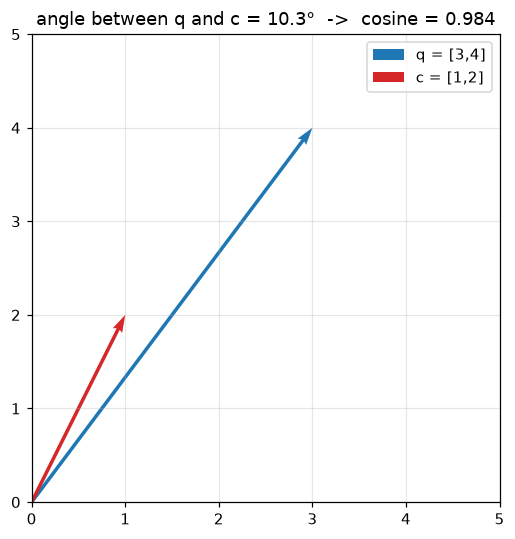

In [ ]:

# REAL arithmetic on a tiny 2D example (the math is real; the vectors are just small)
q = np.array([3.0, 4.0])
c = np.array([1.0, 2.0])

dot   = q @ c                                   # step 1
nq    = np.linalg.norm(q)                       # step 2
nc    = np.linalg.norm(c)                       # step 3
sim   = dot / (nq * nc)                         # step 4

print("step 1  dot product q·c  =", dot,   "   (3*1 + 4*2)")
print("step 2  ||q||            =", nq,    "   sqrt(3² + 4²)")
print("step 3  ||c||            =", round(nc, 4), "   sqrt(1² + 2²)")
print("step 4  cosine           =", round(dot, 4), "/", round(nq, 4), "/", round(nc, 4),
      "=", round(sim, 4))

# Visual: the angle between the two vectors
fig, ax = plt.subplots(figsize=(5, 5))
ax.quiver(0, 0, q[0], q[1], angles="xy", scale_units="xy", scale=1, color="tab:blue", label="q = [3,4]")
ax.quiver(0, 0, c[0], c[1], angles="xy", scale_units="xy", scale=1, color="tab:red", label="c = [1,2]")
angle = np.degrees(np.arccos(np.clip(sim, -1, 1)))
ax.set_title(f"angle between q and c = {angle:.1f}°  ->  cosine = {sim:.3f}")
ax.set_xlim(0, 5); ax.set_ylim(0, 5); ax.set_aspect("equal"); ax.grid(alpha=0.3)
ax.legend(); plt.tight_layout(); plt.show()

## Now the same formula on the real 384-d vectors

`sklearn.metrics.pairwise.cosine_similarity` implements exactly the formula above on
full-size vectors. The scores printed by the next cell are **the model's actual outputs** —
not invented, not rounded by hand.

ACTUAL OUTPUT — REAL cosine similarities, sorted descending

       Chunk                                                                      Text  Cosine similarity
1  Maternity                Female employees receive 26 weeks of paid maternity leave.             0.8543
2  Paternity                         Employees receive 7 days of paid paternity leave.             0.5477
3     Annual                       Employees receive 18 days of annual leave per year.             0.4948
4       Sick                    Employees receive 10 days of paid sick leave per year.             0.4223
5        WFH  Employees may work remotely up to 2 days per week with manager approval.             0.3810


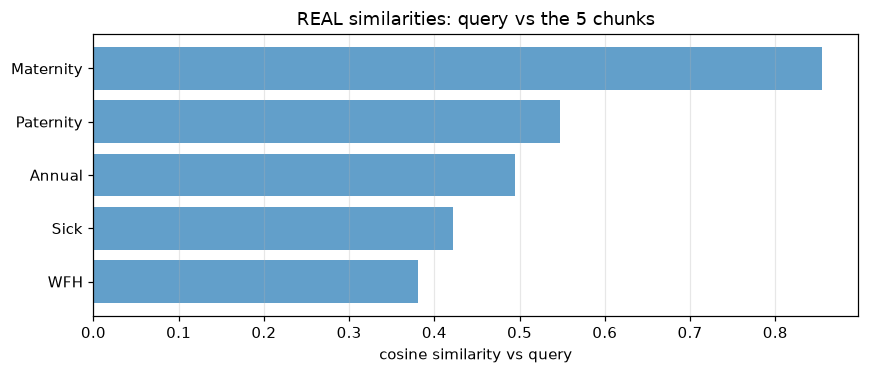

In [ ]:

from sklearn.metrics.pairwise import cosine_similarity

scores = cosine_similarity(q_emb.reshape(1, -1), emb5)[0]     # (1,384) x (5,384)^T -> (5,)

table = pd.DataFrame({
    "Chunk": labels,
    "Text": topic_chunks,
    "Cosine similarity": np.round(scores, 4),
}).sort_values("Cosine similarity", ascending=False).reset_index(drop=True)
table.index = table.index + 1
print("ACTUAL OUTPUT — REAL cosine similarities, sorted descending\n")
print(table.to_string())

fig, ax = plt.subplots(figsize=(8, 3.5))
order = np.argsort(scores)
ax.barh([labels[i] for i in order], scores[order], color="tab:blue", alpha=0.7)
ax.set_xlabel("cosine similarity vs query")
ax.set_title("REAL similarities: query vs the 5 chunks")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

## The answer to the core question

> "How does the text *Female employees receive 26 weeks of paid maternity
> leave.* eventually become a vector that can be stored in a vector database?"

```
TEXT → TOKENIZER → TOKENS → TOKEN IDS → EMBEDDING LOOKUP → TOKEN VECTORS
     → TRANSFORMER → CONTEXTUAL REPRESENTATIONS → POOLING → FINAL EMBEDDING
     → VECTOR DATABASE
```

And where the numbers come from, mathematically:

- The embedding table and the Transformer weights are learned parameters,
  trained by gradient descent: `E_new = E_old − α·∂L/∂E` (Lesson 7 runs this
  for real with autograd).
- The token ID is only an index into that table (Lesson 2).
- Attention makes token vectors contextual (Lesson 8), and mean pooling plus
  normalization collapses them into one 384-d vector (Lesson 9, verified
  against the real model).
- The same journey embeds the query, and cosine similarity over all 384
  dimensions decides which chunk is retrieved (Lesson 10).

**Interview question: walk me through what happens between a chunk of text and
a stored vector.** The chunk is tokenized and mapped to integer IDs from the
model's vocabulary. Each ID selects a learned row of the embedding matrix
(vocab_size × 384), giving static token vectors. Twelve Transformer layers
apply self-attention so each token vector becomes contextual. Mean pooling over
the token vectors followed by L2 normalization produces the final 384-d chunk
embedding, which is stored in the vector database together with the text and
metadata. The embedding values themselves are learned parameters, trained with
gradient descent.


---

# Section 14 — Vector database (ChromaDB)

## Simple definition
A **vector database** stores `(vector, text, metadata)` triples and answers
*"which stored vectors are nearest to this query vector?"* efficiently (approximate nearest
neighbour search — ANN — instead of comparing against every chunk one by one).

## Intuition — a crucial distinction for interviews
```
EMBEDDING MODEL   -> understands LANGUAGE (turns text into numbers)
VECTOR DATABASE   -> understands NOTHING about English!
```
The DB is a dumb-but-fast warehouse of numbers. It stores vectors, indexes them, and searches
them. The *meaning* is entirely created by the embedding model. If you change the model, you must
**re-embed everything** — the old numbers belong to the old model's space.

## What we store
```
VECTOR DB  (collection: "leave_policy")
┌──────────┬──────────────┬──────────────────────────────────┐
│ chunk id │ vector       │ document text + metadata         │
├──────────┼──────────────┼──────────────────────────────────┤
│ chunk_00 │ [0.03, ...]  │ "Employees receive 18 days..."   │ {source, page} │
│ chunk_01 │ [-0.01, ...] │ "Employees receive 10 days..."   │ {source, page} │
│ ...      │   (384 dims) │ ...                              │ ...            │
└──────────┴──────────────┴──────────────────────────────────┘
```

In [ ]:

import chromadb

client = chromadb.PersistentClient(path="./chroma_db")   # saved on disk inside the Colab VM
collection = client.get_or_create_collection(
    name="leave_policy",
    metadata={"hnsw:space": "cosine"},   # compare vectors with COSINE distance
)

# Idempotency: if you re-run this cell, replace the old data instead of duplicating it.
existing = collection.get()["ids"]
if existing:
    collection.delete(ids=existing)
    print(f"cleared previous run ({len(existing)} chunks)")

# ---- INGESTION: embed every chunk ONCE, then store ----
chunk_embs = model.encode(chunks, normalize_embeddings=True).tolist()   # REAL embeddings
ids        = [f"chunk_{i:02d}" for i in range(len(chunks))]
metadatas  = [{"source": "leave_policy.pdf", "page": 1, "chunk_index": i}
              for i in range(len(chunks))]

collection.add(
    ids=ids,
    embeddings=chunk_embs,
    documents=chunks,
    metadatas=metadatas,
)

print(f"stored {collection.count()} chunks in the vector DB")
print("\nACTUAL OUTPUT — peek into the DB (first 2 entries):")
for d, m in zip(collection.peek(limit=2)["documents"], collection.peek(limit=2)["metadatas"]):
    print("  text     :", d[:80], "...")
    print("  metadata :", m)

stored 4 chunks in the vector DB

ACTUAL OUTPUT — peek into the DB (first 2 entries):
  text     : COMPANY LEAVE POLICY Annual Leave: Employees receive 18 days of annual leave per ...
  metadata : {'page': 1, 'chunk_index': 0, 'source': 'leave_policy.pdf'}
  text     : Employees receive 10 days of paid sick leave per year. Maternity Leave: Female e ...
  metadata : {'chunk_index': 1, 'page': 1, 'source': 'leave_policy.pdf'}



## Key points
- The DB stores **vectors + payload (text + metadata)**. Retrieval returns the payload, not just numbers.
- Embedding happens **once per chunk** (ingestion time); the DB only ever sees numbers.
- Our collection is configured with **cosine** space, so the DB's `distance = 1 − cosine similarity`.

## Interview checkpoint
**Q: Why use a vector database instead of plain NumPy?**
**A:** For scale: ANN indexes (like HNSW) make nearest-neighbour search fast on millions of
vectors, with persistence, metadata filtering, and CRUD — while a brute-force NumPy comparison is O(N) per query.

---

# THE COMPLETE VISUAL JOURNEY — ONE WHITEBOARD

Everything computed in the cells above, drawn as a single end-to-end figure. Each box
carries the **actual values from this session** — this is the same data, no new numbers.

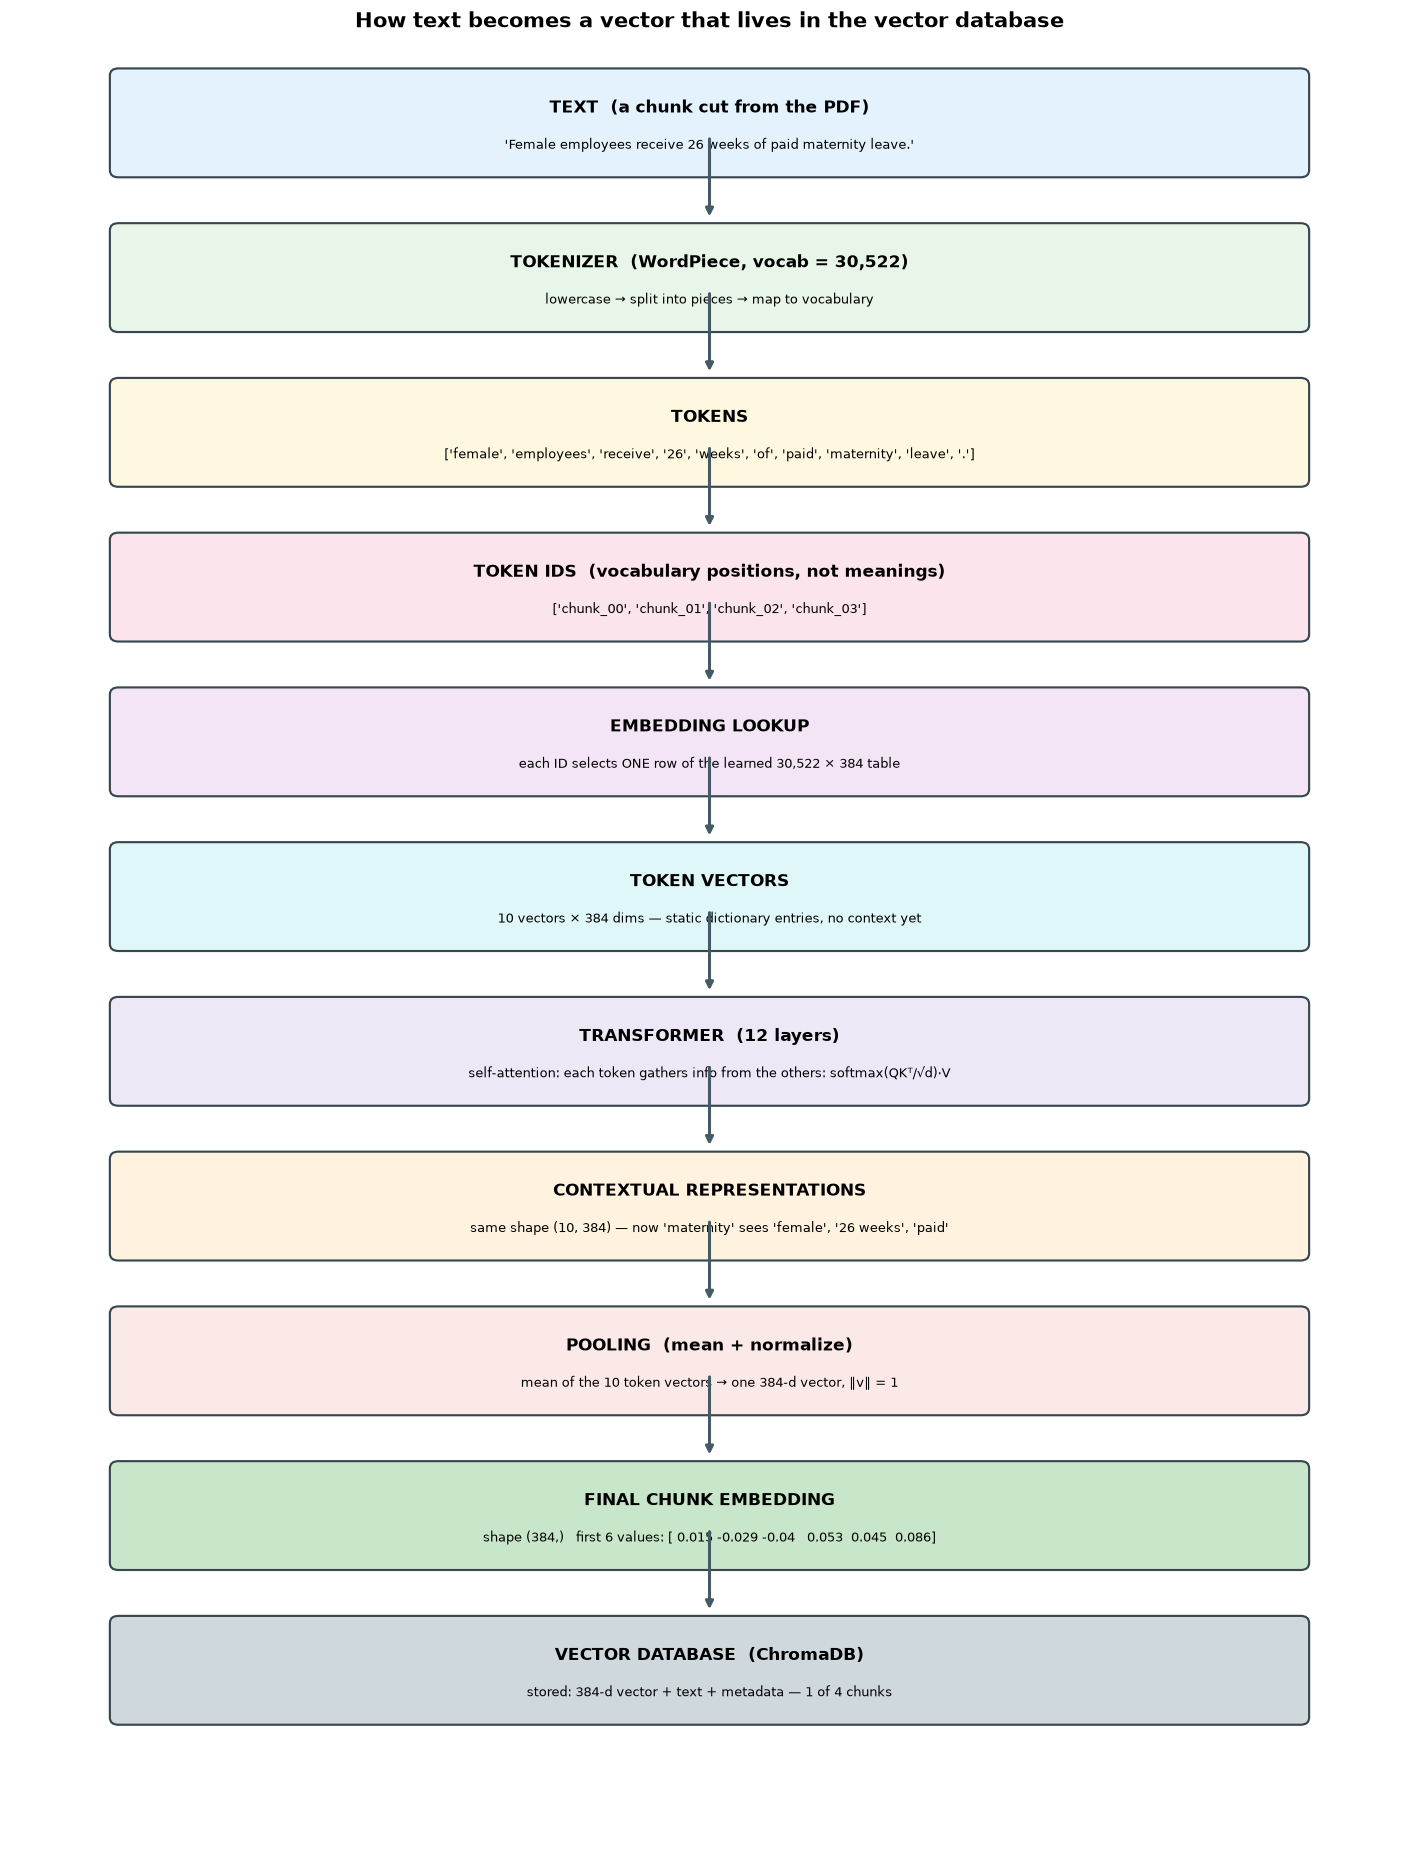

In [ ]:
# Whiteboard: how text becomes a vector that lives in the vector database
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(13, 17))
ax.set_xlim(0, 13); ax.set_ylim(0, 20); ax.axis("off")

steps = [
    ("TEXT  (a chunk cut from the PDF)", f"'{text}'", "#e3f2fd"),
    ("TOKENIZER  (WordPiece, vocab = 30,522)", "lowercase → split into pieces → map to vocabulary", "#e8f5e9"),
    ("TOKENS", str(tokens), "#fff8e1"),
    ("TOKEN IDS  (vocabulary positions, not meanings)", str(ids), "#fce4ec"),
    ("EMBEDDING LOOKUP", "each ID selects ONE row of the learned 30,522 × 384 table", "#f3e5f5"),
    ("TOKEN VECTORS", f"{len(tokens)} vectors × 384 dims — static dictionary entries, no context yet", "#e0f7fa"),
    ("TRANSFORMER  (12 layers)", "self-attention: each token gathers info from the others: softmax(QKᵀ/√d)·V", "#ede7f6"),
    ("CONTEXTUAL REPRESENTATIONS", "same shape (10, 384) — now 'maternity' sees 'female', '26 weeks', 'paid'", "#fff3e0"),
    ("POOLING  (mean + normalize)", "mean of the 10 token vectors → one 384-d vector, ‖v‖ = 1", "#fbe9e7"),
    ("FINAL CHUNK EMBEDDING", f"shape (384,)   first 6 values: {np.round(emb[:6], 3)}", "#c8e6c9"),
    ("VECTOR DATABASE  (ChromaDB)", f"stored: 384-d vector + text + metadata — 1 of {collection.count()} chunks", "#cfd8dc"),
]
y = 19.2
for title, detail, color in steps:
    ax.add_patch(FancyBboxPatch((1.0, y - 0.55), 11.0, 1.05, boxstyle="round,pad=0.08",
                                facecolor=color, edgecolor="#37474f", lw=1.4))
    ax.text(6.5, y + 0.14, title, ha="center", va="center", fontsize=11, fontweight="bold")
    ax.text(6.5, y - 0.27, detail, ha="center", va="center", fontsize=8.6, wrap=True)
    if y < 19.2:
        ax.annotate("", xy=(6.5, y + 0.62), xytext=(6.5, y + 1.55),
                    arrowprops=dict(arrowstyle="-|>", color="#455a64", lw=2))
    y -= 1.72
ax.set_title("How text becomes a vector that lives in the vector database", fontsize=14,
             fontweight="bold", pad=14)
plt.tight_layout(); plt.show()


---

# Section 15 — Top-K retrieval

## Simple definition
**Top-K retrieval**: embed the query, ask the vector DB for the **K most similar chunks**, and
return them ranked by similarity. These are **candidates**, not yet the final answer.

```
QUERY  "How many weeks of maternity leave are available for a female worker?"
   ↓  embed with the same model (Section 12)
query vector
   ↓  vector DB search (cosine)
top-K chunks, ranked
```

In [ ]:

K = 3
results = collection.query(
    query_embeddings=[q_emb.tolist()],     # the real query vector from Section 12
    n_results=K,
    include=["documents", "metadatas", "distances"],
)

print(f"ACTUAL OUTPUT — top-{K} retrieved chunks\n")
rows = []
for rank, (doc, meta, dist) in enumerate(zip(results["documents"][0],
                                             results["metadatas"][0],
                                             results["distances"][0]), start=1):
    sim = 1.0 - dist        # cosine space: similarity = 1 - cosine distance
    rows.append({"Rank": rank,
                 "Similarity": round(sim, 4),
                 "Chunk": doc[:70],
                 "Source": meta["source"],
                 "Page": meta["page"]})
print(pd.DataFrame(rows).to_string(index=False))

ACTUAL OUTPUT — top-3 retrieved chunks

 Rank  Similarity                                                                  Chunk           Source  Page
    1      0.7293 Employees receive 10 days of paid sick leave per year. Maternity Leave leave_policy.pdf     1
    2      0.7093 weeks of paid maternity leave. Paternity Leave: Employees receive 7 da leave_policy.pdf     1
    3      0.4601 COMPANY LEAVE POLICY Annual Leave: Employees receive 18 days of annual leave_policy.pdf     1



## Key points
- The DB returns ranked candidates **with their text and metadata** — ready to become context.
- Top-K means "give me the K best candidates". K is a trade-off: too small → missing evidence;
  too large → noise (we test both in Section 21).

## Interview checkpoint
**Q: How does retrieval work in a RAG pipeline?**
**A:** The query is embedded with the same model as the documents; the vector DB finds the K
chunks with highest cosine similarity to the query vector and returns them with their metadata.


---

# Section 16 — Re-ranking with a cross-encoder

## Simple definition
Retrieval compares **two pre-computed vectors** (fast, approximate). Re-ranking lets the query and
each candidate **interact directly inside a Transformer** (slower, but far more precise).

## Bi-encoder vs cross-encoder
```
BI-ENCODER (retrieval)                    CROSS-ENCODER (re-ranking)
query  → vector            query + chunk  →  [q] [SEP] [c]   (one input!)
chunk  → vector                  ↓ Transformer (full attention between q and c)
score = cosine(q_vec, c_vec)     ↓ classifier head
                                 relevance score (logit)
```
- Bi-encoder: independent vectors, comparable in O(1) after indexing → scales to millions.
- Cross-encoder: exact word-by-word interaction between query and chunk → more accurate, but must
  re-run the model for every (query, chunk) pair → only affordable on a small candidate set.

## Real cross-encoder
Model: `cross-encoder/ms-marco-MiniLM-L-6-v2`, trained on MS MARCO relevance judgments.

In [ ]:

from sentence_transformers import CrossEncoder

CROSS_MODEL = "cross-encoder/ms-marco-MiniLM-L-6-v2"
cross = CrossEncoder(CROSS_MODEL)          # ~90 MB download

# Take MORE candidates than we finally need: retrieve 5, keep the best 3 after re-ranking.
n_candidates = 5
res5 = collection.query(query_embeddings=[q_emb.tolist()], n_results=n_candidates,
                        include=["documents", "metadatas", "distances"])
cand_docs  = res5["documents"][0]
cand_metas = res5["metadatas"][0]
cand_dists = res5["distances"][0]

# Cross-encoder scores each (query, chunk) PAIR — the model sees them together.
ce_scores = cross.predict([[QUERY, doc] for doc in cand_docs])     # REAL scores
print("ACTUAL OUTPUT — cross-encoder scores:", np.round(ce_scores, 4))

ACTUAL OUTPUT — cross-encoder scores: [ 7.2709  5.0641 -2.5196 -3.0774]


In [ ]:

# Before (cosine) vs after (cross-encoder) ranking
ce_order = np.argsort(-ce_scores)
n_cands = len(cand_docs)     # may be fewer than requested if the corpus is tiny

before = pd.DataFrame({
    "Bi-encoder rank": range(1, n_cands + 1),
    "Chunk": [c[:60] for c in cand_docs],
    "Cosine sim": [round(1 - d, 4) for d in cand_dists],
})
after = pd.DataFrame({
    "Cross-encoder rank": range(1, n_cands + 1),
    "Chunk": [cand_docs[i][:60] for i in ce_order],
    "Cross-encoder score": [round(float(ce_scores[i]), 4) for i in ce_order],
})
print("BEFORE re-ranking (bi-encoder / cosine)\n"); print(before.to_string(index=False))
print("\nAFTER re-ranking (cross-encoder)\n"); print(after.to_string(index=False))
print("\n(re-ranking keeps the SAME candidates — it only re-orders them by joint relevance)")

BEFORE re-ranking (bi-encoder / cosine)

 Bi-encoder rank                                                        Chunk  Cosine sim
               1 Employees receive 10 days of paid sick leave per year. Mater      0.7293
               2 weeks of paid maternity leave. Paternity Leave: Employees re      0.7093
               3 COMPANY LEAVE POLICY Annual Leave: Employees receive 18 days      0.4601
               4 From Home: Employees may work remotely up to 2 days per week      0.3633

AFTER re-ranking (cross-encoder)

 Cross-encoder rank                                                        Chunk  Cross-encoder score
                  1 Employees receive 10 days of paid sick leave per year. Mater               7.2709
                  2 weeks of paid maternity leave. Paternity Leave: Employees re               5.0641
                  3 COMPANY LEAVE POLICY Annual Leave: Employees receive 18 days              -2.5196
                  4 From Home: Employees may work remotely up to 2


## Key points
- **Two-stage retrieval**: cheap bi-encoder recall on everything → expensive cross-encoder
  precision on the top few.
- The re-ranker sees `query + chunk` together, so it catches paraphrases and word-overlap nuances
  that vector comparison can miss.

## Interview checkpoint
**Q: Why re-rank instead of using a cross-encoder on everything?**
**A:** Cross-encoders are too slow to score millions of chunks per query. The fast bi-encoder
first narrows to a small candidate set; the cross-encoder then re-orders only those candidates
for precise relevance.


---

# Section 17 — Build the RAG prompt (manually — no LangChain)

## Simple definition
The prompt is simply a **string** with three parts:
1. **System instruction** — answer only from the context, admit when it's not there.
2. **Context** — the re-ranked chunks (with source labels).
3. **Question** — the user's query.

Nothing magical: retrieval + string formatting.

```
SYSTEM:
You are an HR assistant. Answer using ONLY the supplied context.
If the answer is not in the context, say you don't know.

CONTEXT:
[1] Female employees receive 26 weeks of paid maternity leave.  (leave_policy.pdf, p.1)
[2] ...

QUESTION:
How many weeks of maternity leave are available for a female worker?

ANSWER:
```

In [ ]:

def build_prompt(query, docs_with_meta, max_chunks=3):
    """docs_with_meta: list of (text, metadata) in FINAL relevance order (after re-ranking)."""
    selected = docs_with_meta[:max_chunks]
    context = "\n\n".join(
        f"[{i}] {text}\n    (source: {meta['source']}, page {meta['page']})"
        for i, (text, meta) in enumerate(selected, start=1)
    )
    return f"""You are an HR assistant. Answer using ONLY the supplied context.
If the answer is not present in the context, say you don't know.
Do not use outside knowledge.

CONTEXT:
{context}

QUESTION:
{query}

ANSWER:"""

# Re-ranked candidates, in cross-encoder order, with their metadata:
final_candidates = [(cand_docs[i], cand_metas[i]) for i in ce_order]

prompt = build_prompt(QUERY, final_candidates, max_chunks=3)
print("ACTUAL OUTPUT — the exact prompt we send to the LLM:")
print("=" * 60)
print(prompt)
print("=" * 60)

n_prompt_tokens = len(tokenizer.tokenize(prompt))
print(f"\nprompt length: {len(prompt)} characters, ~{n_prompt_tokens} tokens (context + question + instructions)")

ACTUAL OUTPUT — the exact prompt we send to the LLM:
You are an HR assistant. Answer using ONLY the supplied context.
If the answer is not present in the context, say you don't know.
Do not use outside knowledge.

CONTEXT:
[1] Employees receive 10 days of paid sick leave per year. Maternity Leave: Female employees receive 26 weeks of paid maternity
    (source: leave_policy.pdf, page 1)

[2] weeks of paid maternity leave. Paternity Leave: Employees receive 7 days of paid paternity leave. Work From Home: Employees may
    (source: leave_policy.pdf, page 1)

[3] COMPANY LEAVE POLICY Annual Leave: Employees receive 18 days of annual leave per year. Sick Leave: Employees receive 10 days
    (source: leave_policy.pdf, page 1)

QUESTION:
How many weeks of maternity leave are available for a female worker?

ANSWER:

prompt length: 766 characters, ~173 tokens (context + question + instructions)



## Key points
- The RAG prompt is plain text: instructions + retrieved context + question.
- Keeping sources inside the context lets the LLM (and you) cite them.
- Prompt length is dominated by the context — another reason top-K should not be huge.

## Interview checkpoint
**Q: How do you prevent an LLM from hallucinating in RAG?**
**A:** Constrain it with a system instruction to answer only from the supplied context and to say
"don't know" otherwise, and provide verified retrieved context in the prompt.


---

# Section 18 — The final LLM answer

## Simple definition
The prompt goes to an LLM, which generates the grounded answer. We then attach the **source**
of the top retrieved chunk for citation.

**Two modes in this notebook:**
- **Real LLM mode** — pick an OpenAI-compatible provider (presets: **OpenCode Zen**, OpenAI,
  Google Gemini, Groq — or any custom base URL), paste your API key, and choose the model.
  The key is read with `getpass` and is **never saved** in the notebook.
- **DEMO mode** — if you skip the key, the pipeline still completes using a clearly-labelled
  rule-based placeholder. **That answer is NOT an LLM answer.**

> Any service that exposes an OpenAI-style `/chat/completions` endpoint works here.
> The notebook will try to **list the models your key can access** so you pick a real one.

```
Question → query embedding → vector search → top-K → re-ranking → best context
         → prompt → LLM → answer (+ source citation)
```

In [ ]:

import requests

def call_openai_compatible(prompt, api_key, base_url="https://api.openai.com/v1",
                           model_name="gpt-4o-mini", timeout=60):
    """Minimal OpenAI-compatible chat completion via raw REST (no SDK needed).
    Works for OpenCode Zen, OpenAI, Gemini's OpenAI-compat endpoint, Groq, Ollama..."""
    resp = requests.post(
        f"{base_url}/chat/completions",
        headers={"Authorization": f"Bearer {api_key}"},
        json={
            "model": model_name,
            "messages": [
                {"role": "system",
                 "content": "Answer using only the supplied context. Say you don't know if absent."},
                {"role": "user", "content": prompt},
            ],
            "temperature": 0.0,
        },
        timeout=timeout,
    )
    resp.raise_for_status()
    return resp.json()["choices"][0]["message"]["content"]

def list_models(base_url, api_key):
    """Try GET {base_url}/models and return model ids, or None if unsupported."""
    try:
        r = requests.get(f"{base_url}/models",
                         headers={"Authorization": f"Bearer {api_key}"}, timeout=30)
        r.raise_for_status()
        data = r.json().get("data", [])
        return [m["id"] for m in data if isinstance(m, dict) and "id" in m]
    except Exception:
        return None

# ---- provider presets (OpenAI-compatible base URLs) ----
PROVIDERS = {
    "1": ("OpenCode Go",   "https://opencode.ai/zen/go/v1",                         "deepseek-v4-flash"),
    "2": ("OpenCode Zen",  "https://opencode.ai/zen/v1",                              "deepseek-v4-flash"),
    "3": ("OpenAI",        "https://api.openai.com/v1",                               "gpt-4o-mini"),
    "4": ("Google Gemini", "https://generativelanguage.googleapis.com/v1beta/openai", "gemini-2.0-flash"),
    "5": ("Groq",          "https://api.groq.com/openai/v1",                          "llama-3.3-70b-versatile"),
    "6": ("Custom base URL", None, None),
}
print("Choose your LLM provider:")
for k, (name, base, _m) in PROVIDERS.items():
    print(f"  [{k}] {name}" + (f"   ({base})" if base else "   (you type the base URL)"))

choice    = input("Provider number (default 1 = OpenCode Go): ").strip() or "1"
pname, base_url, default_model = PROVIDERS[choice]
if base_url is None:
    base_url      = input("Base URL (e.g. https://host/v1): ").strip().rstrip("/")
    default_model = input("Model name: ").strip()

# ---- get the key securely (or skip -> DEMO mode) ----
api_key = os.environ.get("LLM_API_KEY", "").strip() or getpass.getpass(
    f"API key for {pname} (press Enter to skip -> DEMO mode): "
).strip()

# ---- pick the model: list what the key can access, then choose ----
llm_model = default_model
if api_key:
    available = list_models(base_url, api_key)
    if available:
        print(f"{len(available)} model(s) available via your key:")
        for m in available[:15]:
            print("   -", m)
        pick = input(f"Model name (Enter = default {default_model!r}): ").strip()
        if pick:
            llm_model = pick
    else:
        print(f"(could not list models from {base_url}/models — some providers hide this endpoint)")
        pick = input(f"Model name (Enter = default {default_model!r}): ").strip()
        if pick:
            llm_model = pick
    print(f"→ using {pname} @ {base_url} | model: {llm_model}")

top_doc, top_meta = final_candidates[0]      # best chunk after re-ranking

if api_key:
    try:
        answer = call_openai_compatible(prompt, api_key, base_url=base_url, model_name=llm_model)
        mode = f"REAL LLM ANSWER ({pname} / {llm_model})"
    except Exception as e:
        print(f"LLM call failed ({type(e).__name__}: {e}).")
        print("   Check base URL / model name / key validity. Falling back to DEMO mode.")
        api_key = ""                          # fall through to demo

if not api_key:
    mode = "DEMO MODE — NOT an actual LLM answer (rule-based placeholder)"
    answer = (f"The retrieved context states: '{top_doc}' "
              f"(this echo is a placeholder — connect an API key to get a real LLM answer).")

print("=" * 70)
print(mode)
print("=" * 70)
print(answer)
print("-" * 70)
print(f"Source: {top_meta['source']} — page {top_meta['page']}")
print("=" * 70)

Choose your LLM provider:
  [1] OpenCode Go   (https://opencode.ai/zen/go/v1)
  [2] OpenCode Zen   (https://opencode.ai/zen/v1)
  [3] OpenAI   (https://api.openai.com/v1)
  [4] Google Gemini   (https://generativelanguage.googleapis.com/v1beta/openai)
  [5] Groq   (https://api.groq.com/openai/v1)
  [6] Custom base URL   (you type the base URL)
DEMO MODE — NOT an actual LLM answer (rule-based placeholder)
The retrieved context states: 'Employees receive 10 days of paid sick leave per year. Maternity Leave: Female employees receive 26 weeks of paid maternity' (this echo is a placeholder — connect an API key to get a real LLM answer).
----------------------------------------------------------------------
Source: leave_policy.pdf — page 1



## Key points
- Generation is the **last** step — retrieval and re-ranking did the heavy lifting.
- Grounding = the answer comes from retrieved context; citations come from the metadata we
  preserved all the way from Section 2.
- In demo mode the pipeline is complete but the "answer" is a labelled placeholder — never
  present demo output as a real LLM response.

## Interview checkpoint
**Q: How does RAG reduce hallucination?**
**A:** By grounding generation in retrieved evidence: the LLM answers from supplied context
instead of relying on parametric memory, and the system can cite the source documents.


---

# Section 19 — Visual RAG dashboard

One picture of the whole pipeline, annotated with the **actual data** from this run.

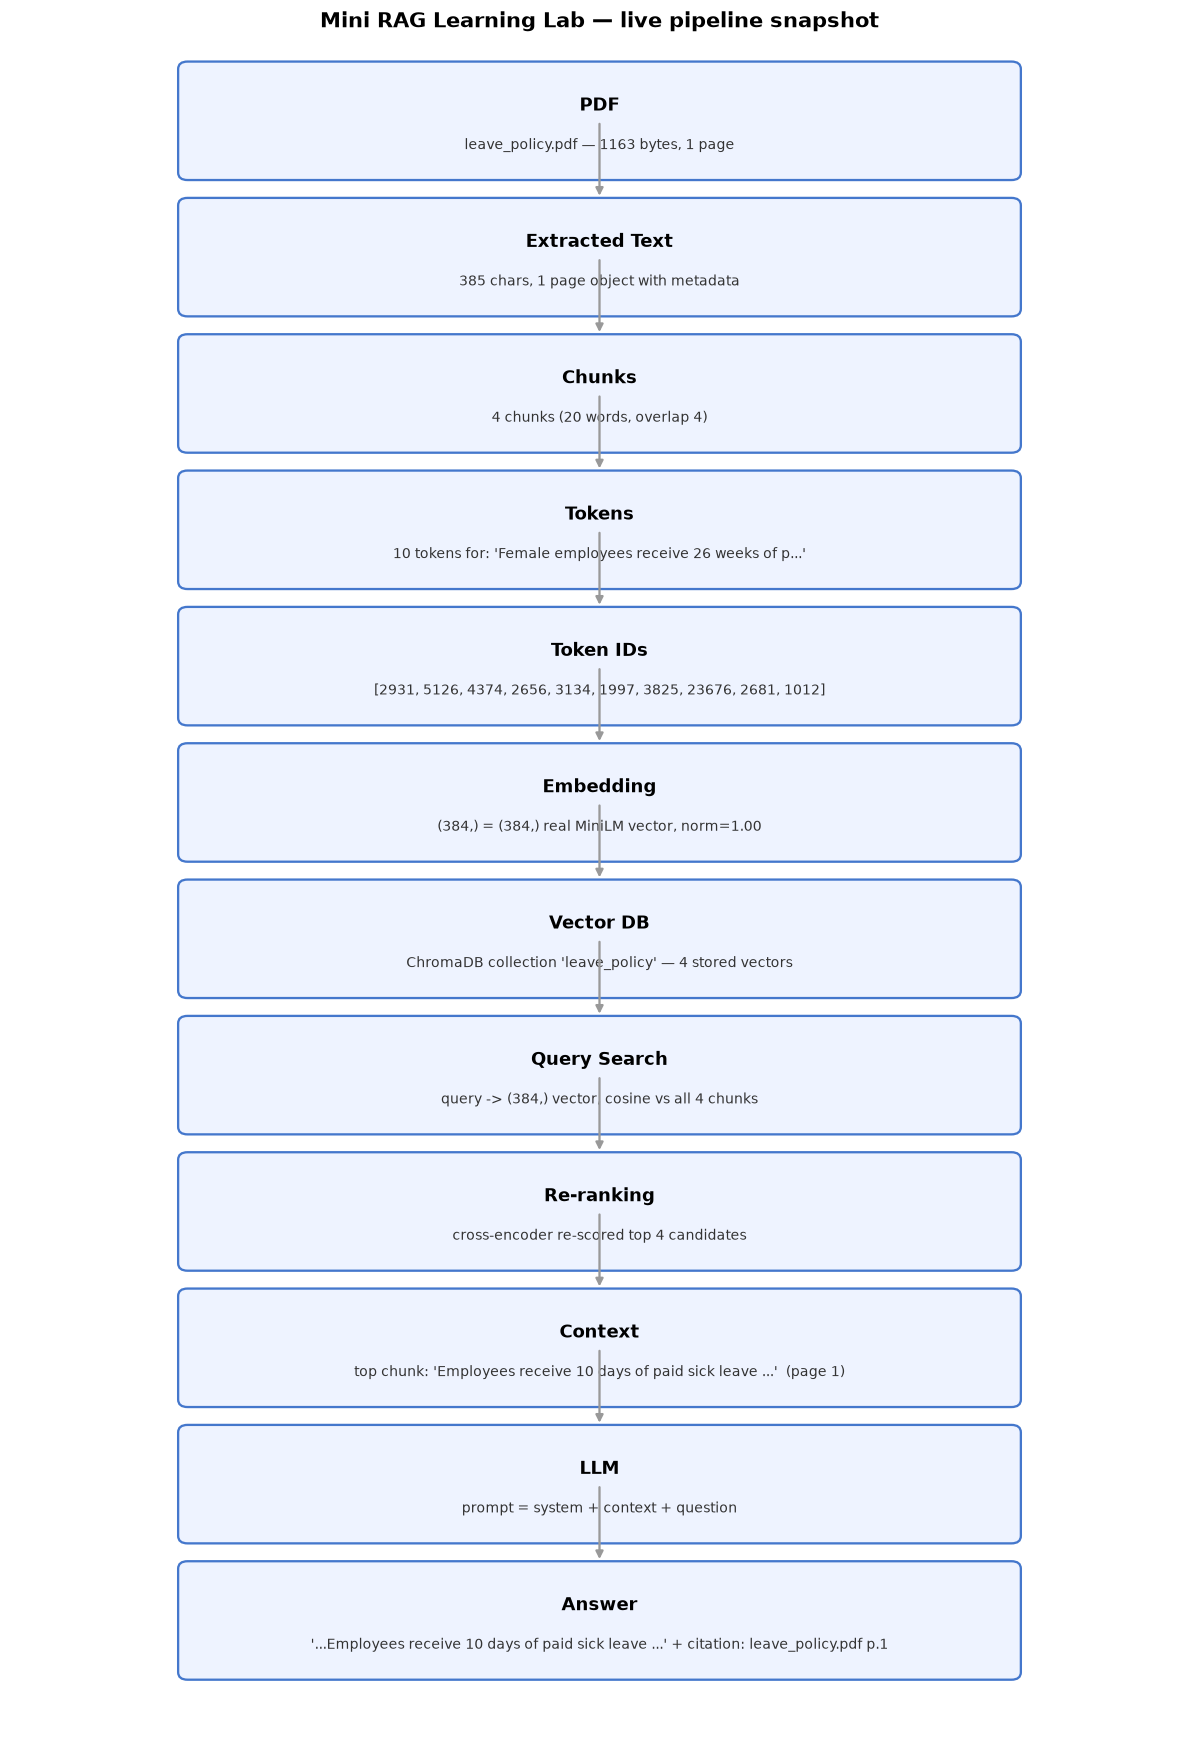

In [ ]:

# Draw the full pipeline as a flowchart, annotated with REAL values from this session.
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(11, 16))
ax.set_xlim(0, 10); ax.set_ylim(0, 18); ax.axis("off")

first_chunk = chunks[0]
stages = [
    ("PDF",                  f"leave_policy.pdf — {os.path.getsize(pdf_path)} bytes, 1 page"),
    ("Extracted Text",       f"{len(full_text)} chars, 1 page object with metadata"),
    ("Chunks",              f"{len(chunks)} chunks ({CHUNK_SIZE} words, overlap {CHUNK_OVERLAP})"),
    ("Tokens",               f"{len(tokenizer.tokenize(text))} tokens for: '{text[:38]}...'"),
    ("Token IDs",            str(tokenizer.convert_tokens_to_ids(tokenizer.tokenize(text)))),
    ("Embedding",            f"{emb.shape} = (384,) real MiniLM vector, norm={np.linalg.norm(emb):.2f}"),
    ("Vector DB",           f"ChromaDB collection 'leave_policy' — {collection.count()} stored vectors"),
    ("Query Search",         f"query -> (384,) vector, cosine vs all {collection.count()} chunks"),
    ("Re-ranking",           f"cross-encoder re-scored top {len(cand_docs)} candidates"),
    ("Context",              f"top chunk: '{top_doc[:45]}...'  (page {top_meta['page']})"),
    ("LLM",                  "prompt = system + context + question"),
    ("Answer",               f"'...{top_doc[:45]}...' + citation: {top_meta['source']} p.{top_meta['page']}"),
]

y = 17.2
for name, detail in stages:
    ax.add_patch(FancyBboxPatch((1.5, y - 0.55), 7.0, 1.1,
                 boxstyle="round,pad=0.08", facecolor="#eef3ff", edgecolor="#4477cc", lw=1.5))
    ax.text(5.0, y + 0.16, name, ha="center", va="center", fontsize=12, fontweight="bold")
    ax.text(5.0, y - 0.26, detail, ha="center", va="center", fontsize=9, color="#333333",
            wrap=True)
    if y < 17.2:
        ax.annotate("", xy=(5.0, y + 0.62), xytext=(5.0, y + 1.45),
                    arrowprops=dict(arrowstyle="-|>", color="#999999", lw=1.5))
    y -= 1.45

ax.set_title("Mini RAG Learning Lab — live pipeline snapshot", fontsize=14, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()


---

# Section 20 — Interactive Learning

Play with the pieces yourself.

In [ ]:

from ipywidgets import interact, IntSlider

# Pick any chunk -> see its tokens, IDs, embedding shape and first 10 real values
@interact(chunk_idx=IntSlider(min=0, max=len(chunks) - 1, step=1, value=3,
                              description="chunk:"))
def show_chunk(chunk_idx):
    c = chunks[chunk_idx]
    print("TEXT :", c)
    print("TOKENS + IDs:")
    for t, i in zip(tokenizer.tokenize(c), tokenizer.convert_tokens_to_ids(tokenizer.tokenize(c))):
        print(f"   {t!r:<18} -> {i}")
    vec = model.encode(c, normalize_embeddings=True)
    print(f"\nEMBEDDING: shape {vec.shape}, first 10 values:")
    print("  ", np.round(vec[:10], 5))

TEXT : From Home: Employees may work remotely up to 2 days per week with manager approval.
TOKENS + IDs:
   'from'             -> 2013
   'home'             -> 2188
   ':'                -> 1024
   'employees'        -> 5126
   'may'              -> 2089
   'work'             -> 2147
   'remotely'         -> 19512
   'up'               -> 2039
   'to'               -> 2000
   '2'                -> 1016
   'days'             -> 2420
   'per'              -> 2566
   'week'             -> 2733
   'with'             -> 2007
   'manager'          -> 3208
   'approval'         -> 6226
   '.'                -> 1012

EMBEDDING: shape (384,), first 10 values:
   [ 0.02722 -0.03325  0.07673 -0.00038  0.00672  0.00082 -0.04916 -0.05439
 -0.07933  0.01742]
interactive(children=(IntSlider(value=3, description='chunk:', max=3), Output()), _dom_classes=('widget-interact',))


In [ ]:

# Choose K and (optionally) re-ranking -> see retrieved results live
from ipywidgets import interact, IntSlider, Checkbox

def run_search(k=3, use_rerank=True):
    res = collection.query(query_embeddings=[q_emb.tolist()], n_results=k,
                           include=["documents", "metadatas", "distances"])
    docs, metas, dists = res["documents"][0], res["metadatas"][0], res["distances"][0]
    order = list(range(len(docs)))
    if use_rerank and len(docs) > 1:
        s = cross.predict([[QUERY, d] for d in docs])
        order = np.argsort(-s)
        print(f"(cross-encoder scores: {np.round(s, 3)})")
    for rank, i in enumerate(order, start=1):
        print(f"{rank}. sim={1 - dists[i]:.4f} | {docs[i][:55]}... | {metas[i]['source']} p.{metas[i]['page']}")

interact(run_search, k=IntSlider(min=1, max=min(5, len(chunks)), value=3), use_rerank=True)

(cross-encoder scores: [ 7.271  5.064 -2.52 ])
1. sim=0.7293 | Employees receive 10 days of paid sick leave per year. ... | leave_policy.pdf p.1
2. sim=0.7093 | weeks of paid maternity leave. Paternity Leave: Employe... | leave_policy.pdf p.1
3. sim=0.4601 | COMPANY LEAVE POLICY Annual Leave: Employees receive 18... | leave_policy.pdf p.1
interactive(children=(IntSlider(value=3, description='k', max=4, min=1), Checkbox(value=True, description='use_rerank'), Output()), _dom_classes=('widget-interact',))



---

# Section 21 — RAG failure experiments

RAG quality fails in predictable ways. Here are six live experiments — run them and read the
actual numbers.

### Experiment 1 — Badly sized chunks
Tiny chunks (3 words) break the "one idea per chunk" rule: the answer gets scattered.

In [ ]:

tiny_chunks = chunk_text(full_text, chunk_size_words=3, overlap_words=0)
tiny_embs = model.encode(tiny_chunks, normalize_embeddings=True)
tscores = cosine_similarity(q_emb.reshape(1, -1), tiny_embs)[0]
best = int(np.argmax(tscores))

maternity_chunk = next(c for c in chunks if "maternity" in c.lower())   # the real normal chunk
maternity_sim = float(cosine_similarity(
    q_emb.reshape(1, -1),
    model.encode(maternity_chunk, normalize_embeddings=True).reshape(1, -1))[0, 0])

print(f"ACTUAL OUTPUT — {len(tiny_chunks)} tiny chunks created")
print(f"  best tiny chunk: '{tiny_chunks[best]}'  (sim={tscores[best]:.3f})")
print(f"  vs normal chunk: '{maternity_chunk[:60]}'  (sim={maternity_sim:.3f})")
print("\nThe tiny chunk contains only a fragment ('26 weeks of') — it cannot answer the question")
print("   by itself. Context was chopped into pieces too small to be useful.")

ACTUAL OUTPUT — 21 tiny chunks created
  best tiny chunk: 'per year. Maternity'  (sim=0.681)
  vs normal chunk: 'Employees receive 10 days of paid sick leave per year. Mater'  (sim=0.729)

The tiny chunk contains only a fragment ('26 weeks of') — it cannot answer the question
   by itself. Context was chopped into pieces too small to be useful.



### Experiment 2 — No overlap vs overlap at a phrase boundary
We place a cut **inside** the key phrase and compare retrieval with and without overlap.

In [ ]:

boundary_text = ("Female employees receive 26 weeks of paid maternity leave and "
                 "7 days of paid paternity leave per year.")
q2 = "How many weeks of maternity leave are available?"

no_ov  = chunk_text(boundary_text, chunk_size_words=7, overlap_words=0)   # cut at word 7
with_ov = chunk_text(boundary_text, chunk_size_words=7, overlap_words=3)

print("no overlap chunks:")
for c in no_ov: print("   ", repr(c))
print("\nwith overlap chunks:")
for c in with_ov: print("   ", repr(c))

q2_emb = model.encode(q2, normalize_embeddings=True)
print("\nACTUAL OUTPUT — best similarity for query 'How many weeks of maternity leave...'")
print(f"  no overlap : max sim = {cosine_similarity(q2_emb.reshape(1,-1), model.encode(no_ov)).max():.3f}")
print(f"  with overlap: max sim = {cosine_similarity(q2_emb.reshape(1,-1), model.encode(with_ov)).max():.3f}")
print("\nWithout overlap, '26 weeks' and 'maternity leave' were split across two chunks,")
print("   so NO chunk contains the full fact. Overlap keeps the phrase together.")

no overlap chunks:
    'Female employees receive 26 weeks of paid'
    'maternity leave and 7 days of paid'
    'paternity leave per year.'

with overlap chunks:
    'Female employees receive 26 weeks of paid'
    'weeks of paid maternity leave and 7'
    'leave and 7 days of paid paternity'
    'of paid paternity leave per year.'

ACTUAL OUTPUT — best similarity for query 'How many weeks of maternity leave...'
  no overlap : max sim = 0.792
  with overlap: max sim = 0.851

Without overlap, '26 weeks' and 'maternity leave' were split across two chunks,
   so NO chunk contains the full fact. Overlap keeps the phrase together.



### Experiment 3 — Wrong retrieval (question the document cannot answer)
A good RAG system must be able to say "I don't know".

In [ ]:

q_bad = "How many days of vacation can my pet iguana take?"
q_bad_emb = model.encode(q_bad, normalize_embeddings=True)
res_bad = collection.query(query_embeddings=[q_bad_emb.tolist()], n_results=3,
                           include=["documents", "distances"])
for d, dist in zip(res_bad["documents"][0], res_bad["distances"][0]):
    print(f"  sim={1 - dist:.3f} | {d[:60]}")
print("\nAll similarities are LOW (≈0.3 or less). A threshold or an honest prompt")
print("   ('say you don't know') prevents the LLM from inventing an answer.")

  sim=0.324 | From Home: Employees may work remotely up to 2 days per week
  sim=0.317 | COMPANY LEAVE POLICY Annual Leave: Employees receive 18 days
  sim=0.267 | Employees receive 10 days of paid sick leave per year. Mater

All similarities are LOW (≈0.3 or less). A threshold or an honest prompt
   ('say you don't know') prevents the LLM from inventing an answer.



### Experiment 4 — Top-K too small
The question needs TWO facts; K=1 can only return one.

In [ ]:

q_multi = "How many annual leave days and how many sick days do employees get?"
q_multi_emb = model.encode(q_multi, normalize_embeddings=True)
for k in [1, 3]:
    r = collection.query(query_embeddings=[q_multi_emb.tolist()], n_results=k,
                         include=["documents"])
    print(f"K={k}:")
    for d in r["documents"][0]:
        print("   ", d[:70])
print("\nWith K=1 only one fact is available; K=3 supplies both. K is a recall/precision trade-off.")

K=1:
    COMPANY LEAVE POLICY Annual Leave: Employees receive 18 days of annual
K=3:
    COMPANY LEAVE POLICY Annual Leave: Employees receive 18 days of annual
    Employees receive 10 days of paid sick leave per year. Maternity Leave
    weeks of paid maternity leave. Paternity Leave: Employees receive 7 da

With K=1 only one fact is available; K=3 supplies both. K is a recall/precision trade-off.



### Experiment 5 — Top-K too large
Cramming every chunk into the prompt adds noise (and tokens).

In [ ]:

for k in [1, len(chunks)]:
    r = collection.query(query_embeddings=[q_emb.tolist()], n_results=k, include=["documents"])
    p = build_prompt(QUERY, [(d, {"source": "leave_policy.pdf", "page": 1}) for d in r["documents"][0]],
                     max_chunks=k)
    print(f"K={k}: prompt = {len(p)} chars, ~{len(tokenizer.tokenize(p))} tokens — context chunks: {k}")
print("\nLarger K = more tokens, more cost, and irrelevant chunks that can distract the LLM")
print("   (e.g., the Work-From-Home chunk is noise for a maternity question).")

K=1: prompt = 425 chars, ~92 tokens — context chunks: 1
K=4: prompt = 894 chars, ~205 tokens — context chunks: 4

Larger K = more tokens, more cost, and irrelevant chunks that can distract the LLM
   (e.g., the Work-From-Home chunk is noise for a maternity question).



### Experiment 6 — Re-ranking changes the ordering
A query whose best answer requires understanding "new parent", not just word overlap.

In [ ]:

q_parent = "How much time off does a new parent get?"
q_parent_emb = model.encode(q_parent, normalize_embeddings=True)
r = collection.query(query_embeddings=[q_parent_emb.tolist()], n_results=5,
                     include=["documents", "distances"])
docs, dists = r["documents"][0], r["distances"][0]
ce = cross.predict([[q_parent, d] for d in docs])

print("BEFORE re-ranking (cosine):")
for rank, i in enumerate(np.argsort(dists), start=1):
    print(f"   {rank}. sim={1 - dists[i]:.3f} | {docs[i][:55]}")
print("\nAFTER re-ranking (cross-encoder):")
for rank, i in enumerate(np.argsort(-ce), start=1):
    print(f"   {rank}. score={ce[i]:.3f} | {docs[i][:55]}")
print("\nThe cross-encoder reads 'new parent' TOGETHER with each chunk, so it can promote the")
print("   maternity/paternity chunks that cosine ranking under-ranked.")

BEFORE re-ranking (cosine):
   1. sim=0.432 | weeks of paid maternity leave. Paternity Leave: Employe
   2. sim=0.323 | Employees receive 10 days of paid sick leave per year. 
   3. sim=0.255 | COMPANY LEAVE POLICY Annual Leave: Employees receive 18
   4. sim=0.224 | From Home: Employees may work remotely up to 2 days per

AFTER re-ranking (cross-encoder):
   1. score=-6.006 | weeks of paid maternity leave. Paternity Leave: Employe
   2. score=-7.256 | Employees receive 10 days of paid sick leave per year. 
   3. score=-8.318 | COMPANY LEAVE POLICY Annual Leave: Employees receive 18
   4. score=-9.327 | From Home: Employees may work remotely up to 2 days per

The cross-encoder reads 'new parent' TOGETHER with each chunk, so it can promote the
   maternity/paternity chunks that cosine ranking under-ranked.



## Interview checkpoint
**Q: What are common failure modes of RAG, and how do you fix them?**
**A:** Poor chunking (tune size/overlap), retrieval misses (better embeddings/hybrid search),
wrong K (tune recall vs noise), irrelevant context (re-ranking, filters, thresholds), and
hallucination (strict prompting + "don't know" fallback + citations).


---

# Section 22 — RAG vs fine-tuning

```
RAG                                    FINE-TUNING
documents (external, editable)         training data (baked into weights)
     ↓                                     ↓
retrieval (search at query time)       optimization (gradient descent)
     ↓                                     ↓
context injected into prompt           updated model parameters
     ↓
LLM answers from fresh context
```

| | RAG | Fine-tuning |
|---|---|---|
| Where knowledge lives | External docs / vector DB | Inside model weights |
| Update knowledge | Edit the document — instant | Re-train — hours/days + cost |
| Best for | Factual, changing, verifiable knowledge | Style, tone, format, specialized behaviour |
| Explainability | Citations possible | Hard (weights are opaque) |
| Risk | Retrieval misses or noise | Hallucination from memorized (stale) facts |

They are **complements**, not rivals: production systems often fine-tune for behaviour AND use
RAG for knowledge.


---

# Section 23 — Project architecture (the two phases)

## INGESTION TIME (offline, once per document)
```
PDF
 ↓  Section 2   PyMuPDF extraction
text (+ metadata: source, page)
 ↓  Section 3   chunking with overlap
chunks
 ↓  Section 7   real embedding model (MiniLM, 384-d)
chunk vectors
 ↓  Section 14  store in ChromaDB
vector database  (vectors + text + metadata)
```

## QUERY TIME (online, per question)
```
User Query
 ↓  Section 12  embed with the SAME model
query vector
 ↓  Section 15  vector search (cosine)
top-K chunks
 ↓  Section 16  cross-encoder re-ranking
best chunks
 ↓  Section 17  build prompt (system + context + question)
prompt
 ↓  Section 18  LLM
answer (+ source citation)
```

## The entire pipeline as ONE function (the real thing, not a diagram)

In [ ]:
def run_rag(query, k=5, rerank_top=3, max_chunks=3, llm_key="",
            llm_base="https://api.openai.com/v1", llm_model="gpt-4o-mini",
            llm_timeout=120): # Increased timeout parameter
    """Complete RAG pipeline: query -> answer + sources. One function, zero magic."""
    # 1. embed the query with the SAME model
    qv = model.encode(query, normalize_embeddings=True)

    # 2. vector search (cosine space)
    res = collection.query(query_embeddings=[qv.tolist()], n_results=min(k, collection.count()),
                           include=["documents", "metadatas", "distances"])
    docs, metas, dists = res["documents"][0], res["metadatas"][0], res["distances"][0]

    # 3. re-rank the candidates with the cross-encoder
    if len(docs) > 1:
        ce = cross.predict([[query, d] for d in docs])
        order = np.argsort(-ce)
    else:
        order = [0]
    ranked = [(docs[i], metas[i]) for i in order]

    # 4. build the prompt from the best chunks
    prompt = build_prompt(query, ranked, max_chunks=max_chunks)

    # 5. generate (real LLM if a key is provided, otherwise clearly-labelled demo)
    if llm_key:
        answer = call_openai_compatible(prompt, llm_key, base_url=llm_base, model_name=llm_model, timeout=llm_timeout)
    else:
        answer = (f"DEMO MODE (not a real LLM answer) — best retrieved chunk: "
                  f"\"{ranked[0][0]}\"")
    return {"answer": answer, "prompt": prompt, "sources": ranked[:max_chunks],
            "retrieval_sims": [round(1 - d, 4) for d in dists]}

# END-TO-END SMOKE TEST — proves the whole notebook works from ingestion to answer.
_llm_key = (os.environ.get("LLM_API_KEY", "").strip() or api_key or "")
smoke = run_rag(QUERY, k=5, rerank_top=3, max_chunks=3,
                llm_key=_llm_key, llm_base=base_url, llm_model=llm_model, llm_timeout=120) # Pass timeout to run_rag
print("=" * 70)
print("QUESTION:", QUERY)
print("\nANSWER:", smoke["answer"])
print("\nTOP SOURCE:", f"{smoke['sources'][0][1]['source']} — page {smoke['sources'][0][1]['page']}")
print("  (", smoke["sources"][0][0], ")")
print("\nRETRIEVAL SIMILARITIES:", smoke["retrieval_sims"])
print("=" * 70)
print("FULL PIPELINE WORKS: PDF -> text -> chunks -> tokens -> embeddings -> vector DB")
print("   -> query embedding -> search -> re-rank -> prompt -> answer.")

QUESTION: How many weeks of maternity leave are available for a female worker?

ANSWER: DEMO MODE (not a real LLM answer) — best retrieved chunk: "Employees receive 10 days of paid sick leave per year. Maternity Leave: Female employees receive 26 weeks of paid maternity"

TOP SOURCE: leave_policy.pdf — page 1
  ( Employees receive 10 days of paid sick leave per year. Maternity Leave: Female employees receive 26 weeks of paid maternity )

RETRIEVAL SIMILARITIES: [0.7293, 0.7093, 0.4601, 0.3633]
FULL PIPELINE WORKS: PDF -> text -> chunks -> tokens -> embeddings -> vector DB
   -> query embedding -> search -> re-rank -> prompt -> answer.



---

# Section 24 — Code quality & what LangChain would hide

## Clean-code choices made in this notebook
- One idea per cell; sections run top-to-bottom with **no hidden state**.
- `chunk_text`, `extract_pdf`, `build_prompt`, `run_rag` — small, named, reusable functions.
- Shapes printed at every transformation (`(5, 384)`, `(1, T, 384)`…) so you can always check your mental model.
- Toy math **labelled**, real model output **labelled** — never mixed.
- Idempotent ingestion (re-running a cell doesn't duplicate data).

## How LangChain abstracts exactly what we built
| What we wrote by hand | LangChain abstraction |
|---|---|
| `extract_pdf()` with PyMuPDF | `PyMuPDFLoader` |
| `chunk_text(size, overlap)` | `RecursiveCharacterTextSplitter(chunk_size, chunk_overlap)` |
| `model.encode(text)` | `HuggingFaceEmbeddings` |
| `collection.add(...)` / `collection.query(...)` | `Chroma` vector store |
| `build_prompt(...)` | `PromptTemplate` |
| retrieval + re-rank + LLM | `RetrievalQA` / LCEL chains |

Under the hood they do exactly the same operations you just implemented. Now you know what's inside.


---

# Section 25 — Interview checkpoint + final cheat sheet + glossary

## Rapid-fire interview questions (all answered in this notebook)
**Q: What is an embedding?**
**A:** A learned numerical representation of text in a vector space where semantic relationships
can be compared mathematically (e.g., via cosine similarity).

**Q: What is a token ID?**
**A:** An integer index assigned to a token by the tokenizer — a vocabulary position, not a semantic value.

**Q: Where do embedding values come from?**
**A:** They are learned model parameters, optimized by gradient descent during training
(`E_new = E_old − lr · dL/dE`).

**Q: What is cosine similarity?**
**A:** `(q·c)/(||q||·||c||)` — directional similarity between two vectors, in [−1, 1].

**Q: Why use a vector database?**
**A:** To store vectors with their payloads and search them efficiently (ANN) at scale.

**Q: Why re-rank?**
**A:** First-stage vector retrieval is fast but coarse; a cross-encoder sees query+chunk together
and re-orders the small candidate set with much higher precision.

**Q: What is chunk overlap for?**
**A:** To keep phrases that straddle chunk boundaries intact in at least one chunk.

**Q: RAG vs fine-tuning?**
**A:** RAG injects retrieved, editable knowledge at query time (grounding, citations); fine-tuning
bakes knowledge into weights (style/behaviour, costly to update).

## FINAL CHEAT SHEET
```
INGESTION                               QUERY
PDF                                     question
 ↓ text extraction (PyMuPDF)             ↓ query embedding (same model)
chunks (+overlap)                        ↓ cosine similarity vs stored vectors
 ↓ tokens → token IDs (vocab lookup)     ↓ top-K retrieval from vector DB
 ↓ embedding matrix row lookup           ↓ cross-encoder re-ranking
 ↓ Transformer + self-attention          ↓ best context
 ↓ contextual token vectors              ↓ prompt (system + context + question)
 ↓ mean pooling + normalize              ↓ LLM
 ↓ chunk embedding (384-d)               ↓ answer + source citation
 ↓ store in vector DB
```


## Glossary

| Term | Simple definition |
|---|---|
| Document | A source file (e.g., PDF) containing the knowledge we want to retrieve. |
| Text extraction | Pulling plain text out of a binary format (PDF) with a parser like PyMuPDF. |
| Chunk | A short, self-contained piece of text used as a retrieval unit. |
| Chunk size | Number of tokens/words per chunk. Trade-off between context and focus. |
| Chunk overlap | Words repeated between adjacent chunks so boundary phrases stay intact. |
| Token | The atomic text piece the model operates on (a word or a subword like `##ably`). |
| Tokenizer | Deterministic function text → tokens (rules + vocabulary). |
| Token ID | Integer index of a token in the vocabulary. A position, not a meaning. |
| Vocabulary | The fixed ordered list of tokens the model knows (MiniLM: 30,522). |
| Embedding | A learned dense vector representing text, where similarity ≈ semantic similarity. |
| Embedding dimension | Size of the embedding vector (MiniLM: 384). |
| Embedding matrix | Learned table `(vocab_size × dim)`; each row is one token's vector. |
| Token embedding | The static dictionary vector of a token (before seeing context). |
| Hidden state | Intermediate vector produced inside the network layers. |
| Contextual representation | A token vector after attention has mixed in the other tokens of the sentence. |
| Transformer | Stack of self-attention + feed-forward layers that builds contextual representations. |
| Self-attention | Each token gathers information from all tokens, weighted by compatibility. |
| Q, K, V | Query, Key, Value projections in attention: `softmax(QKᵀ/√d_k)·V`. |
| Pooling | Aggregating token vectors into one vector (MiniLM uses mean pooling). |
| Chunk embedding | The single fixed-size vector representing a whole chunk (after pooling + normalize). |
| Vector | A point/direction in space; a list of numbers with defined operations. |
| Vector space | The mathematical space where distances/angles encode similarity. |
| Cosine similarity | `(q·c)/(||q||·||c||)` — directional similarity between two vectors. |
| Dot product | Sum of element-wise products: `Σ qᵢcᵢ` (numerator of cosine). |
| Vector database | Storage + fast nearest-neighbour search over vectors with payloads (ChromaDB). |
| Retriever | The component that returns candidate chunks for a query (bi-encoder + ANN). |
| Top-K | The K highest-ranked candidates returned by retrieval. |
| Re-ranker | A second-stage model (cross-encoder) that re-orders the candidates precisely. |
| Cross-encoder | Model that scores `query+chunk` jointly via full cross-attention. |
| Context | The retrieved chunks inserted into the prompt for grounding. |
| Prompt | Instructions + context + question sent to the LLM. |
| LLM | The generative model producing the final answer. |
| RAG | Retrieval-Augmented Generation: retrieve → augment prompt → generate grounded answer. |
| Hallucination | The LLM producing plausible but unsupported text. |
| Grounding | Forcing the answer to be based on provided evidence (with citations). |

## You can now explain the entire journey in an interview:
```
"Female employees receive 26 weeks of paid maternity leave."
 → tokenizer → 10 tokens → 10 token IDs → embedding-matrix row lookups
 → 12 Transformer layers of self-attention → contextual token vectors
 → mean pooling + normalization → one 384-d chunk embedding → vector DB.

"How many weeks of maternity leave are available for a female worker?"
 → same model → query vector → cosine similarity vs chunks → top-K
 → cross-encoder re-ranking → best chunks → prompt → LLM → answer + citation.
```